# 실시간 인플레이션 예측

In [1]:
import pandas as pd
from pandas.tseries.offsets import MonthEnd
from pandas.tseries.offsets import DateOffset

from inf import * # * : 모듈 전체 가져오기

import numpy as np

import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

import joblib

from sklearn.ensemble import ExtraTreesRegressor as EXT

import glob
import os

from tqdm import tqdm
import itertools

from tqdm import notebook
import pickle
idx = pd.IndexSlice

# 빈티지 데이터셋 불러오기 

In [2]:
vintages = pd.date_range('2012-12-02', '2025-06-27', freq='W-FRI')
targets = pd.date_range('2024-05-31', '2025-05-31', freq='M')

In [4]:
targets

DatetimeIndex(['2024-05-31', '2024-06-30', '2024-07-31', '2024-08-31',
               '2024-09-30', '2024-10-31', '2024-11-30', '2024-12-31',
               '2025-01-31', '2025-02-28', '2025-03-31', '2025-04-30',
               '2025-05-31'],
              dtype='datetime64[ns]', freq='M')

In [5]:
DF_vintages = {}

for date in vintages:
    df = pd.read_csv(f'vintages/{date:%Y-%m-%d}.csv', index_col=0)
    df.index = pd.DatetimeIndex(df.index, freq='M')
    DF_vintages[date] = df

In [9]:
date

Timestamp('2025-06-27 00:00:00', freq='W-FRI')

# 하이퍼 파라미터 튜닝, 표본외 예측력 평가(Walk-forward Validation)

## Random Walk

In [10]:
targets

DatetimeIndex(['2024-05-31', '2024-06-30', '2024-07-31', '2024-08-31',
               '2024-09-30', '2024-10-31', '2024-11-30', '2024-12-31',
               '2025-01-31', '2025-02-28', '2025-03-31', '2025-04-30',
               '2025-05-31'],
              dtype='datetime64[ns]', freq='M')

In [13]:
p_results = pd.DataFrame(index=vintages) # 예측치 저장공간

for hor in [0, 3, 12]: # forecasting horizon
    print('\nh =', hor, end='\n')
    
    tms = tqdm(targets, desc=f'target month = ', dynamic_ncols=True)
    for tm in tms:
        tms.set_description(f'target month = {tm.strftime("%Y-%m")}')

        dates, _, _ = get_forecasting_dates(hor, tm, vintages)
        res = pd.DataFrame(index=dates, columns=[tm])
        
        for date in dates:
            _, y = get_train_data_v5(DF_vintages[date])
            y = y.shift(-hor)
            res.loc[date] = y.dropna().iloc[-1]

        res = pd.concat([res], axis=1, keys=[hor])
        p_results = pd.concat([p_results, res], axis=1)

p_results.columns = pd.MultiIndex.from_tuples(p_results.columns)
p_results = p_results.sort_index(axis=1)

fn = f'rw.pkl'  # 매월 모형추정
fol = 'output'
fp = os.path.join(fol, fn)
with open(fp, 'wb') as f:
    pickle.dump(p_results, f)


h = 0


target month = 2025-05: 100%|██████████| 13/13 [00:06<00:00,  2.08it/s]



h = 3


target month = 2025-05: 100%|██████████| 13/13 [00:11<00:00,  1.10it/s]



h = 12


target month = 2025-05: 100%|██████████| 13/13 [00:11<00:00,  1.13it/s]


## ARIMA

In [15]:
# Warning 무시
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

In [16]:
#for p, q, r in tqdm(itertools.product([2, 3], [1, 2], [2, 3])):
for p, q, r in tqdm(itertools.product([3], [1], [3])):

    print('\np, q, r: ', [p, q, r])

    p_results = pd.DataFrame(index=vintages)

    for hor in [0, 3, 12]: # forecasting horizon
        print('\nh = ', hor, end='\n')

        tms = tqdm(targets, desc=f'target month = ', dynamic_ncols=True)
        for tm in tms:
            tms.set_description(f'target month = {tm.strftime("%Y-%m")}')
            
            dates, _, _ = get_forecasting_dates(hor, tm, vintages) # 예측시계별로 타겟월에 대한 첫 예측 빈티지 시점부터 마지막 빈티지 시점까지 반환

            res = pd.DataFrame(index=dates, columns=[tm])
            for date in dates:

                _, y = get_train_data_v5(DF_vintages[date])

                y = y.shift(-hor) # 예측시계에 맞춰 시계열 조정
                arima = sm.tsa.arima.ARIMA(y, order=(p, q, r))
                fitted = arima.fit()
                predicted = fitted.predict(end = tm).iloc[-1]
                res.loc[date] = predicted

            res = pd.concat([res], axis=1, keys=[hor]) # keys=[hor]는 예측시계별로 데이터를 구분
            p_results = pd.concat([p_results, res], axis=1)

    p_results.columns = pd.MultiIndex.from_tuples(p_results.columns) # 예측시계와 타겟월을 멀터 인덱스로 구분
    p_results = p_results.sort_index(axis=1) # 예측시계별로 정렬

    fn = f'arima_p{p}_q{q}_r{r}.pkl'
    fol = 'output'
    fp = os.path.join(fol, fn)
    with open(fp, 'wb') as f:
        pickle.dump(p_results, f) # 예측결과를 파일로 저장

0it [00:00, ?it/s]


p, q, r:  [3, 1, 3]

h =  0


target month = 2025-05: 100%|██████████| 13/13 [01:08<00:00,  5.29s/it]



h =  3


target month = 2025-05: 100%|██████████| 13/13 [02:22<00:00, 10.97s/it]



h =  12


target month = 2025-05: 100%|██████████| 13/13 [02:10<00:00, 10.02s/it]
1it [05:41, 341.55s/it]


## Regression

In [17]:
lm_var0 = ['P_cpi_1', 'GB_cp_3'] # 고정변수
#lm_var1 = ['P_ipi_1', 'P_ipi_2', 'P_ipi_6', 'L_eap_10', 'C_rsi_1',
#           'C_css_1', 'IE_mir_9', 'RE_atpi_1', 'F_fb_1', 'P_adm', 'P_ppi_1']

#lm_var1 = ['P_ipi_6', 'RE_atpi_1', 'F_fb_1', 'P_adm', 'L_eap_10']
lm_var1 = ['P_ipi_6', 'RE_atpi_1'] # 고정변수에 추가로 조합할 변수

lm_models = []
for c in [1, 2]:
    lm_models += [list(i) + lm_var0 for i in itertools.combinations(lm_var1, c)]
# len(lm_models) = 66

In [18]:
lm_models

[['P_ipi_6', 'P_cpi_1', 'GB_cp_3'],
 ['RE_atpi_1', 'P_cpi_1', 'GB_cp_3'],
 ['P_ipi_6', 'RE_atpi_1', 'P_cpi_1', 'GB_cp_3']]

In [21]:
for model, lag, rolling in tqdm(itertools.product(lm_models, [3, 4, 6], [0])):

    print('\nmodel, lag, rolling: ', [model, lag, rolling])
    model_name = '-'.join(model)

    p_results = pd.DataFrame(index=vintages)

    for hor in [0, 3, 12]: # forecasting horizon
        print('\nh:', hor, end = '\n')
        
        for tm in targets:            
            if tm.month == 1:
                print(tm.strftime('%Y-%m'), end=' ')
            else:
               print(tm.strftime('%m'), end=' ')

            dates, _, m1 = get_forecasting_dates(hor, tm, vintages)
            res = pd.DataFrame(index=dates, columns=[tm])
            
            for date in dates:

                X_train, y_train = get_train_data_v5(DF_vintages[date], lag=lag, data_group=3, m1=m1, rolling=rolling, predictors=model)
                eqn = 'y ~ 1 + ' + ' + '.join(X_train.columns.tolist())

                if tm.month in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]:  # 타겟월이 매분기 첫째월인 경우만 모형 추정
                #if tm.month in [1]:        # 타겟월이 1월인 경우만 모형 추정
                    y_train = y_train.shift(-hor).to_frame('y')
                    Xy_train = pd.concat([X_train, y_train], axis=1).dropna(axis=0)
                    reg = smf.ols(eqn, data = Xy_train).fit()
                    joblib.dump(reg, f"model/lm_roll{rolling}_lag{lag}_model{model_name}_{tm.year}-01_h{hor}.pkl")

                predictor = X_train.loc[[m1]]
                predicted = reg.predict(predictor)[0]
                res.loc[date] = predicted

            res = pd.concat([res], axis=1, keys=[hor])
            p_results = pd.concat([p_results, res], axis=1)

    p_results.columns = pd.MultiIndex.from_tuples(p_results.columns)
    p_results = p_results.sort_index(axis=1)

    fn = f'lm_roll{rolling}_lag{lag}_model{model_name}_IN.pkl' 
    fol = 'output'
    fp = os.path.join(fol, fn)
    with open(fp, 'wb') as f:
        pickle.dump(p_results, f)

0it [00:00, ?it/s]


model, lag, rolling:  [['P_ipi_6', 'P_cpi_1', 'GB_cp_3'], 3, 0]

h: 0
05 06 07 08 09 10 11 12 2025-01 02 03 04 05 
h: 3
05 06 07 08 09 10 11 12 2025-01 02 03 04 05 
h: 12
05 06 07 08 09 10 11 12 2025-01 02 03 04 05 

1it [00:53, 53.14s/it]


model, lag, rolling:  [['P_ipi_6', 'P_cpi_1', 'GB_cp_3'], 4, 0]

h: 0
05 06 07 08 09 10 11 12 2025-01 02 03 04 05 
h: 3
05 06 07 08 09 10 11 12 2025-01 02 03 04 05 
h: 12
05 06 07 08 09 10 11 12 2025-01 02 03 04 05 

2it [01:50, 55.55s/it]

...

7it [06:28, 55.36s/it]


model, lag, rolling:  [['P_ipi_6', 'RE_atpi_1', 'P_cpi_1', 'GB_cp_3'], 4, 0]

h: 0
05 06 07 08 09 10 11 12 2025-01 02 03 04 05 
h: 3
05 06 07 08 09 10 11 12 2025-01 02 03 04 05 
h: 12
05 06 07 08 09 10 11 12 2025-01 02 03 04 05 

8it [07:25, 55.86s/it]


model, lag, rolling:  [['P_ipi_6', 'RE_atpi_1', 'P_cpi_1', 'GB_cp_3'], 6, 0]

h: 0
05 06 07 08 09 10 11 12 2025-01 02 03 04 05 
h: 3
05 06 07 08 09 10 11 12 2025-01 02 03 04 05 
h: 12
05 06 07 08 09 10 11 12 2025-01 02 03 04 05 

9it [08:30, 56.75s/it]


## Extremely Randomized Tree(EXT)

In [23]:
#for rolling, lag, md, dn in notebook.tqdm(itertools.product([0], [0], [6, 8, 10], [1, 2])):
#for rolling, lag, md, dn in notebook.tqdm([[0, 0, 6, 1], [0, 0, 8, 1], [0, 0, 10, 1], [0, 0, 8, 2], [0, 0, 10, 2]]):
for rolling, lag, md, dn in notebook.tqdm([[0, 0, 6, 1]]):

    print('\nrolling, lag, md, dn: ', [rolling, lag, md, dn])
    model = EXT(n_estimators=2000, max_features=0.5, max_depth=md, n_jobs=-1) # random_state=0, max_features=1.0

    p_results = pd.DataFrame(index=vintages)

    for hor in [0, 3, 12]:
        print('\nh = ', hor, end = '\n')

        for tm in targets:

            if tm.month == 1:
                print(tm.strftime('%Y-%m'), end=' ')
            else:
                print(tm.strftime('%m'), end=' ')
               
            dates, _, m1 = get_forecasting_dates(hor, tm, vintages)
            res = pd.DataFrame(index=dates, columns=[tm])
            
            for date in dates:

                X_train, y_train = get_train_data_v5(DF_vintages[date], lag=lag, data_group=dn, excl_alt=True, m1=m1, rolling=rolling)
                if hor == 12:
                    X_train = X_train.drop(['P_eir'], axis = 1) # 기대인플레 제외

                if tm.month in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]:  # 타겟월이 매년 1월에만 모형 추정
                    if hor == 0:
                        y_train = y_train.shift(-hor) - y_train.shift(1) # 차분된 값을 타겟으로
                    else:
                        y_train = y_train.shift(-hor) - y_train.shift(0)
                    Xy_train = pd.concat([X_train, y_train], axis=1).dropna(axis=0)
                    model.fit(Xy_train.iloc[:-1, :-1], Xy_train.iloc[:-1, -1])
                    #model.fit(Xy_train.iloc[:, :-1], Xy_train.iloc[:, -1])
                    joblib.dump(model, f"model/ext_roll{rolling}_lag{lag}_d{md}_g{dn}_{tm.year}-01_h{hor}.pkl")

                #_, y = get_train_data(vintages[-1], 0, 0, 0)
                _, y = get_train_data_v5(DF_vintages[vintages[-1]])

                predictor = X_train.loc[[m1]]
                if hor == 0:
                    res.loc[date] = model.predict(predictor) + y.loc[m1 - MonthEnd(1)]
                else:
                    res.loc[date] = model.predict(predictor) + y.loc[m1 - MonthEnd(0)]

            res = pd.concat([res], axis=1, keys=[hor])
            p_results = pd.concat([p_results, res], axis=1)

    p_results.columns = pd.MultiIndex.from_tuples(p_results.columns)
    p_results = p_results.sort_index(axis=1)

    fn = f'ext_roll{rolling}_lag{lag}_d{md}_g{dn}_IN.pkl'  # p1_diff : 1월에만 cpi 차이 예측
    fol = 'output'
    fp = os.path.join(fol, fn)
    with open(fp, 'wb') as f:
        pickle.dump(p_results, f)

  0%|          | 0/1 [00:00<?, ?it/s]


rolling, lag, md, dn:  [0, 0, 6, 1]

h =  0
05 06 07 

KeyboardInterrupt: 

# 모형별 예측치 읽어들이고, mae/rmse, last_pred 계산

In [24]:
# 과거 인플레이션 실제치
_, act = get_train_data_v5(DF_vintages[vintages[-1]])

## RW

In [30]:
# RW
rw_pred = pd.read_pickle('output/rw.pkl')

rw_mae = pd.DataFrame()
rw_rmse = pd.DataFrame()

err = get_error_by_vintage(rw_pred, act)

In [35]:
# RW
rw_pred = pd.read_pickle('output/rw.pkl')

rw_mae = pd.DataFrame()
rw_rmse = pd.DataFrame()

err = get_error_by_vintage(rw_pred, act)
err, rw_mae, rw_rmse = align_error_by_week(err)
rw_pred_last = get_pred_last(rw_pred)

In [39]:
rw_rmse.to_pickle('output/rw_rmse.pkl')
rw_mae.to_pickle('output/rw_mae.pkl')

## ARIMA

In [44]:
# ARIMA
files = glob.glob('output/arima_p3_q1_r3.pkl')
names = [file.split('/')[-1].split('.')[0] for file in files]

arima_pred = get_pred(files, names)
arima_mae, arima_rmse, arima_pred_last = get_eval_last_pred(arima_pred, names, act)

  0%|          | 0/1 [00:00<?, ?it/s]

In [46]:
arima_rmse.to_pickle('output/arima_rmse.pkl')
arima_mae.to_pickle('output/arima_mae.pkl')

## Reg

In [36]:
# lm_models = [['L_eap_10', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#  ['RE_atpi_1', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#  ['F_fb_1', 'P_adm', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#  ['L_eap_10', 'RE_atpi_1', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#  ['RE_atpi_1', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#  ['F_fb_1', 'P_adm', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#  ['L_eap_10', 'P_adm', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#  ['P_ipi_6', 'RE_atpi_1', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#  ['RE_atpi_1', 'P_adm', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#  ['P_ipi_6', 'RE_atpi_1', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#  ['P_ipi_6', 'L_eap_10', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#  ['IE_mir_9', 'RE_atpi_1', 'P_cpi_1', 'P_eir', 'GB_cp_3']]


In [47]:
# lm_models = [['RE_atpi_1', 'P_adm', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#              ['F_fb_1', 'P_adm', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#              ['P_ipi_6', 'RE_atpi_1', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#              ['RE_atpi_1', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#              ['P_ipi_6', 'RE_atpi_1', 'P_cpi_1', 'P_eir' 'GB_cp_3'],
#              ['P_ipi_6', 'RE_atpi_1', 'P_cpi_1', 'GB_cp_3']]
             
lm_pred_files = [f'lm_roll0_lag{l}_model{m}_IN.pkl' for l in [3, 4, 6] for m in ['-'.join(model) for model in lm_models]]

files = glob.glob('output/lm_*')
files = [file for file in files if file.split('\\')[-1] in lm_pred_files]
names = [file.split('\\')[-1].split('.')[0] for file in files]

In [48]:
lm_pred = get_pred(files, names)
lm_mae, lm_rmse, lm_pred_last = get_eval_last_pred(lm_pred, names, act)

for df, data in zip([lm_pred, lm_mae, lm_rmse, lm_pred_last], ['pred', 'mae', 'rmse', 'pred_last']):
    df.to_pickle(f"output/lm_{data}.pkl")

  0%|          | 0/9 [00:00<?, ?it/s]

In [50]:
dfs = []

for res in ['pred', 'mae', 'rmse', 'pred_last']:
    df = pd.read_pickle(f"output/lm_{res}.pkl")
    dfs.append(df)

lm_pred = dfs[0]
lm_mae = dfs[1]
lm_rmse = dfs[2]
lm_pred_last = dfs[3]

## EXT

In [52]:
# EXT
files = glob.glob('output/ext_*')
names = [file.split('\\')[-1].split('.')[0] for file in files]

In [53]:
ext_pred = get_pred(files, names)
ext_mae, ext_rmse, ext_pred_last = get_eval_last_pred(ext_pred, names, act)

  0%|          | 0/1 [00:00<?, ?it/s]

## Ensemble(lm + ext)

In [54]:
lm_best_for_ensemble = []

for hor in [0]:
    lm_best_for_ensemble += lm_mae[hor].iloc[-1].sort_values().index[:10].tolist()
    lm_best_for_ensemble += lm_rmse[hor].iloc[-1].sort_values().index[:10].tolist()

lm_best_for_ensemble = list(set(lm_best_for_ensemble))
#len(lm_best_for_ensemble) = 10

In [55]:
lm_best_for_ensemble

['lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN',
 'lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN',
 'lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN',
 'lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN',
 'lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN',
 'lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN',
 'lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN',
 'lm_roll0_lag4_modelP_ipi_6-P_cpi_1-GB_cp_3_IN',
 'lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN']

In [44]:
# lm_best_for_ensemble = ['lm_roll0_lag6_modelRE_atpi_1:P_adm:P_cpi_1:P_eir:GB_cp_3',
#                         'lm_roll0_lag4_modelF_fb_1:P_adm:P_cpi_1:P_eir:GB_cp_3',
#                         'lm_roll0_lag6_modelP_ipi_6:RE_atpi_1:P_cpi_1:P_eir:GB_cp_3',
#                         'lm_roll0_lag3_modelRE_atpi_1:P_cpi_1:P_eir:GB_cp_3',
#                         'lm_roll0_lag4_modelP_ipi_6:RE_atpi_1:P_cpi_1:GB_cp_3']
# lm_best_for_ensemble

In [56]:
ext_best_for_ensemble = []

for hor in [0]:
    ext_best_for_ensemble += ext_mae[hor].iloc[-1].sort_values().index[:3].tolist()
    ext_best_for_ensemble += ext_rmse[hor].iloc[-1].sort_values().index[:3].tolist()

ext_best_for_ensemble = list(set(ext_best_for_ensemble))

In [57]:
ext_best_for_ensemble

['ext_roll0_lag0_d6_g1_IN']

In [58]:
ens_models = []
for c in [1, 2, 3]:
    ens_models += [list(i) for i in itertools.combinations(lm_best_for_ensemble, c)]

ens_models = [m + [n] for m in ens_models for n in ext_best_for_ensemble] #+ ens_models

In [59]:
ens_models

[['lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN',
  'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN',
  'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN',
  'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN', 'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN',
  'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN',
  'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN',
  'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag4_modelP_ipi_6-P_cpi_1-GB_cp_3_IN', 'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN', 'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN',
  'lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN',
  'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN',
  'lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_c

In [50]:
#get_best_ens_models(ens_models)

In [51]:
#ens_models[18]

In [52]:
# models = ext_best_for_ensemble + lm_best_for_ensemble
# ens_models = []
# for c in [2, 3, len(models)]:
#    ens_models += [list(i) for i in itertools.combinations(models, c)]

In [60]:
ens_models

[['lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN',
  'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN',
  'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN',
  'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN', 'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN',
  'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN',
  'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN',
  'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag4_modelP_ipi_6-P_cpi_1-GB_cp_3_IN', 'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN', 'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN',
  'lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN',
  'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN',
  'lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_c

In [61]:
hors = lm_pred.columns.get_level_values(1).unique().tolist()
target = lm_pred.columns.get_level_values(2).unique().tolist()

big_pred = pd.concat([lm_pred, ext_pred], axis=1)
ens_pred = pd.DataFrame()

for i, model in notebook.tqdm(enumerate(ens_models)):
    pred = big_pred[model]
    df = pd.DataFrame(0, index=vintages, columns=pd.MultiIndex.from_product([hors, targets]))
    for m in pred.columns.get_level_values(0).unique():
        df = df + pred[m]
    df = df / len(model)

    df = pd.concat([df], axis=1, keys=['ens' + str(i)])
    ens_pred = pd.concat([ens_pred, df], axis=1)

ens_pred.to_pickle("output/ens_pred.pkl")
ens_pred = ens_pred.sort_index(axis=1)
ens_mae, ens_rmse, ens_pred_last = get_eval_last_pred(ens_pred, ens_pred.columns.get_level_values(0).unique(), act)
# ens_pred.info()  566 X 325500, 1.4GB

for df, data in zip([ens_pred, ens_mae, ens_rmse, ens_pred_last], ['pred', 'mae', 'rmse', 'pred_last']):
    df.to_pickle(f"output/ens_{data}.pkl")

0it [00:00, ?it/s]

  0%|          | 0/129 [00:00<?, ?it/s]

IndexError: single positional indexer is out-of-bounds

In [54]:
ens_pred.columns.get_level_values(0).unique()

Index(['ens0', 'ens1', 'ens10', 'ens100', 'ens101', 'ens102', 'ens103',
       'ens104', 'ens105', 'ens106',
       ...
       'ens90', 'ens91', 'ens92', 'ens93', 'ens94', 'ens95', 'ens96', 'ens97',
       'ens98', 'ens99'],
      dtype='object', length=129)

In [62]:
dfs = []

for data in ['pred', 'mae', 'rmse', 'pred_last']:
    df = pd.read_pickle(f"output/ens_{data}.pkl")
    dfs.append(df)

ens_pred = dfs[0]
ens_mae = dfs[1]
ens_rmse = dfs[2]
ens_pred_last = dfs[3]

# 모든 전망시계, 모형별 Plot RMSE/MAE

In [65]:
ens_rmse

0                                                               \
         ens0      ens1     ens10    ens100    ens101    ens102    ens103   
-16       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
-15       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
-14       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
-13       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
-12       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
-11       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
-10       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
-9        NaN       NaN       NaN       NaN       NaN       NaN       NaN   
-8   0.345984  0.328744  0.360787  0.362659  0.374764  0.362994  0.349209   
-7   0.270567  0.259016  0.282137  0.280619  0.292062  0.281471  0.272298   
-6   0.271774  0.260382  0.283043  0.281979  0.292676  0.282699  0.273418   
-5   0.172534  0.166264  0.157229  0.148563  0.151480  0.146326  0.144523   
-4   0.202109  0.195292  0.191757  0.184263  0.188516  0.185656  0.182533   
-3   0.198591  0.193008  0.195307  0.185019  0.191622  0.190703  0.182333   
-2   0.198090  0.192791  0.193064  0.183307  0.189974  0.188262  0.180372   
-1   0.196059  0.190874  0.191879  0.182470  0.189081  0.187419  0.179617   

                                   ...        12                      \
       ens104    ens105    ens106  ...     ens90     ens91     ens92   
-16       NaN       NaN       NaN  ...  0.258882  0.308083  0.306642   
-15       NaN       NaN       NaN  ...  0.357628  0.361381  0.321237   
-14       NaN       NaN       NaN  ...  0.357409  0.366925  0.330555   
-13       NaN       NaN       NaN  ...  0.407038  0.393944  0.363861   
-12       NaN       NaN       NaN  ...  0.372062  0.402664  0.375954   
-11       NaN       NaN       NaN  ...  0.427091  0.397874  0.348582   
-10       NaN       NaN       NaN  ...  0.470005  0.432073  0.356934   
-9        NaN       NaN       NaN  ...  0.452957  0.429466  0.359754   
-8   0.361179  0.349473  0.360439  ...  0.467812  0.455283  0.381318   
-7   0.282899  0.273096  0.280842  ...  0.444108  0.439486  0.379123   
-6   0.283445  0.274091  0.282141  ...  0.396050  0.436006  0.422327   
-5   0.146069  0.142374  0.148016  ...  0.405685  0.446431  0.436163   
-4   0.186159  0.184368  0.186941  ...  0.411300  0.452825  0.439345   
-3   0.188756  0.188474  0.193058  ...  0.384588  0.437221  0.410311   
-2   0.186944  0.185817  0.188736  ...  0.374841  0.410852  0.331711   
-1   0.186075  0.185005  0.187896  ...  0.389128  0.416634  0.329147   

                                                                           
        ens93     ens94     ens95     ens96     ens97     ens98     ens99  
-16  0.361410  0.513291  0.553390  0.284936  0.215355  0.195606  0.525589  
-15  0.342964  0.594643  0.631298  0.373674  0.342051  0.268485  0.604998  
-14  0.351620  0.591865  0.624852  0.373977  0.342037  0.273114  0.600690  
-13  0.367560  0.622825  0.657323  0.414370  0.371292  0.315365  0.632218  
-12  0.385235  0.574414  0.604005  0.392105  0.355008  0.302281  0.579864  
-11  0.338778  0.614308  0.648374  0.429673  0.395860  0.323628  0.622423  
-10  0.339985  0.648594  0.683956  0.466908  0.439237  0.346730  0.656712  
-9   0.342457  0.627569  0.657982  0.456267  0.426064  0.339625  0.632189  
-8   0.366655  0.640076  0.664596  0.479145  0.452137  0.361247  0.639683  
-7   0.365032  0.615420  0.634394  0.462355  0.437226  0.358698  0.610959  
-6   0.372769  0.576027  0.588528  0.438521  0.436466  0.354987  0.567891  
-5   0.386003  0.584065  0.594000  0.449605  0.449069  0.369940  0.572966  
-4   0.393352  0.591576  0.599338  0.456947  0.460913  0.378125  0.578917  
-3   0.378397  0.579677  0.584952  0.433717  0.455524  0.354407  0.566569  
-2   0.344831  0.582796  0.588316  0.412275  0.449801  0.322943  0.571106  
-1   0.347921  0.591144  0.596849  

In [66]:
ens_rmse = ens_rmse.iloc[1:,:]
ens_mae = ens_mae.iloc[1:,:]
lm_rmse = lm_rmse.iloc[1:,:]
lm_mae = lm_mae.iloc[1:,:]
ext_rmse = ext_rmse.iloc[1:,:]
ext_mae = ext_mae.iloc[1:,:]
arima_rmse = arima_rmse.iloc[1:,:]
arima_mae = arima_mae.iloc[1:,:]
rw_rmse = rw_rmse.iloc[1:,:]
rw_mae = rw_mae.iloc[1:,:]

In [ ]:
#from matplotlib.ticker import MultipleLocator

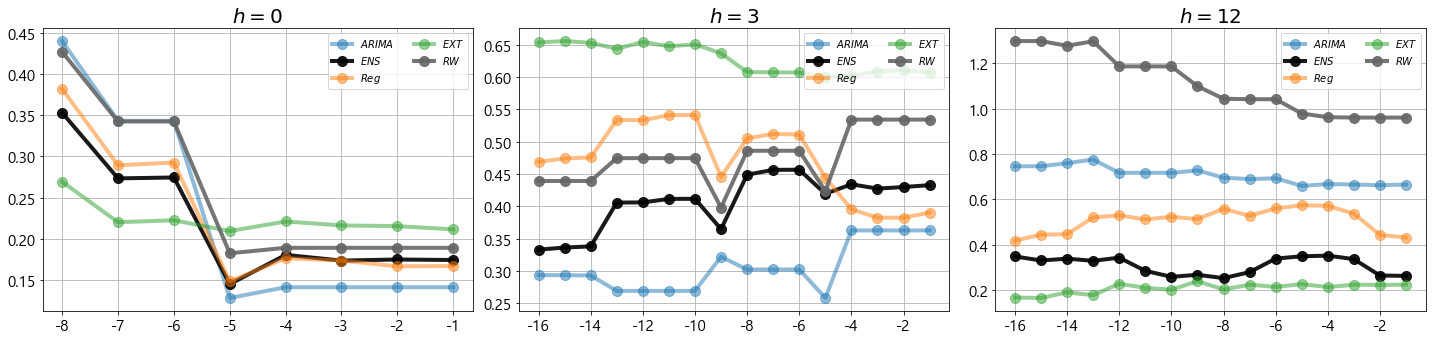

In [65]:
plot_rmse(arima_rmse, ens_rmse, lm_rmse,ext_rmse, rw_rmse, best=1, good=1, title='', ncol=2, loc='upper right', figsize=(20, 5), 
          bbox_to_anchor=(1, 1), fontsize=10)

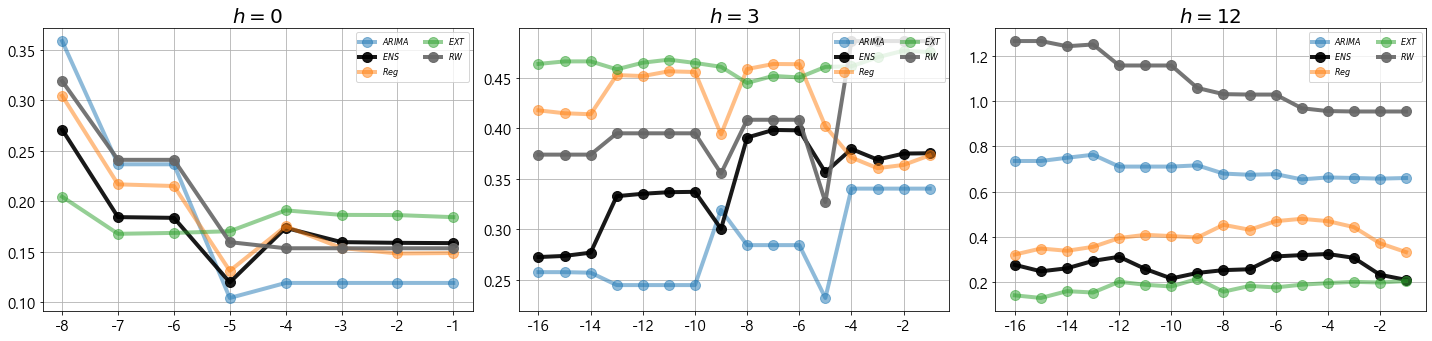

In [62]:
plot_mae(arima_mae, ens_mae, lm_mae, ext_mae, rw_mae, best=1, good=1, title='', ncol=2, loc='upper right', figsize=(20, 5), 
          bbox_to_anchor=(1, 1), fontsize=8)

# Plot MAE/RMSE

(MAE) arima_p3_q1_r3: 0.217 
(RMSE) arima_p3_q1_r3: 0.284 
rw mae: 0.260 rw rmse: 0.296


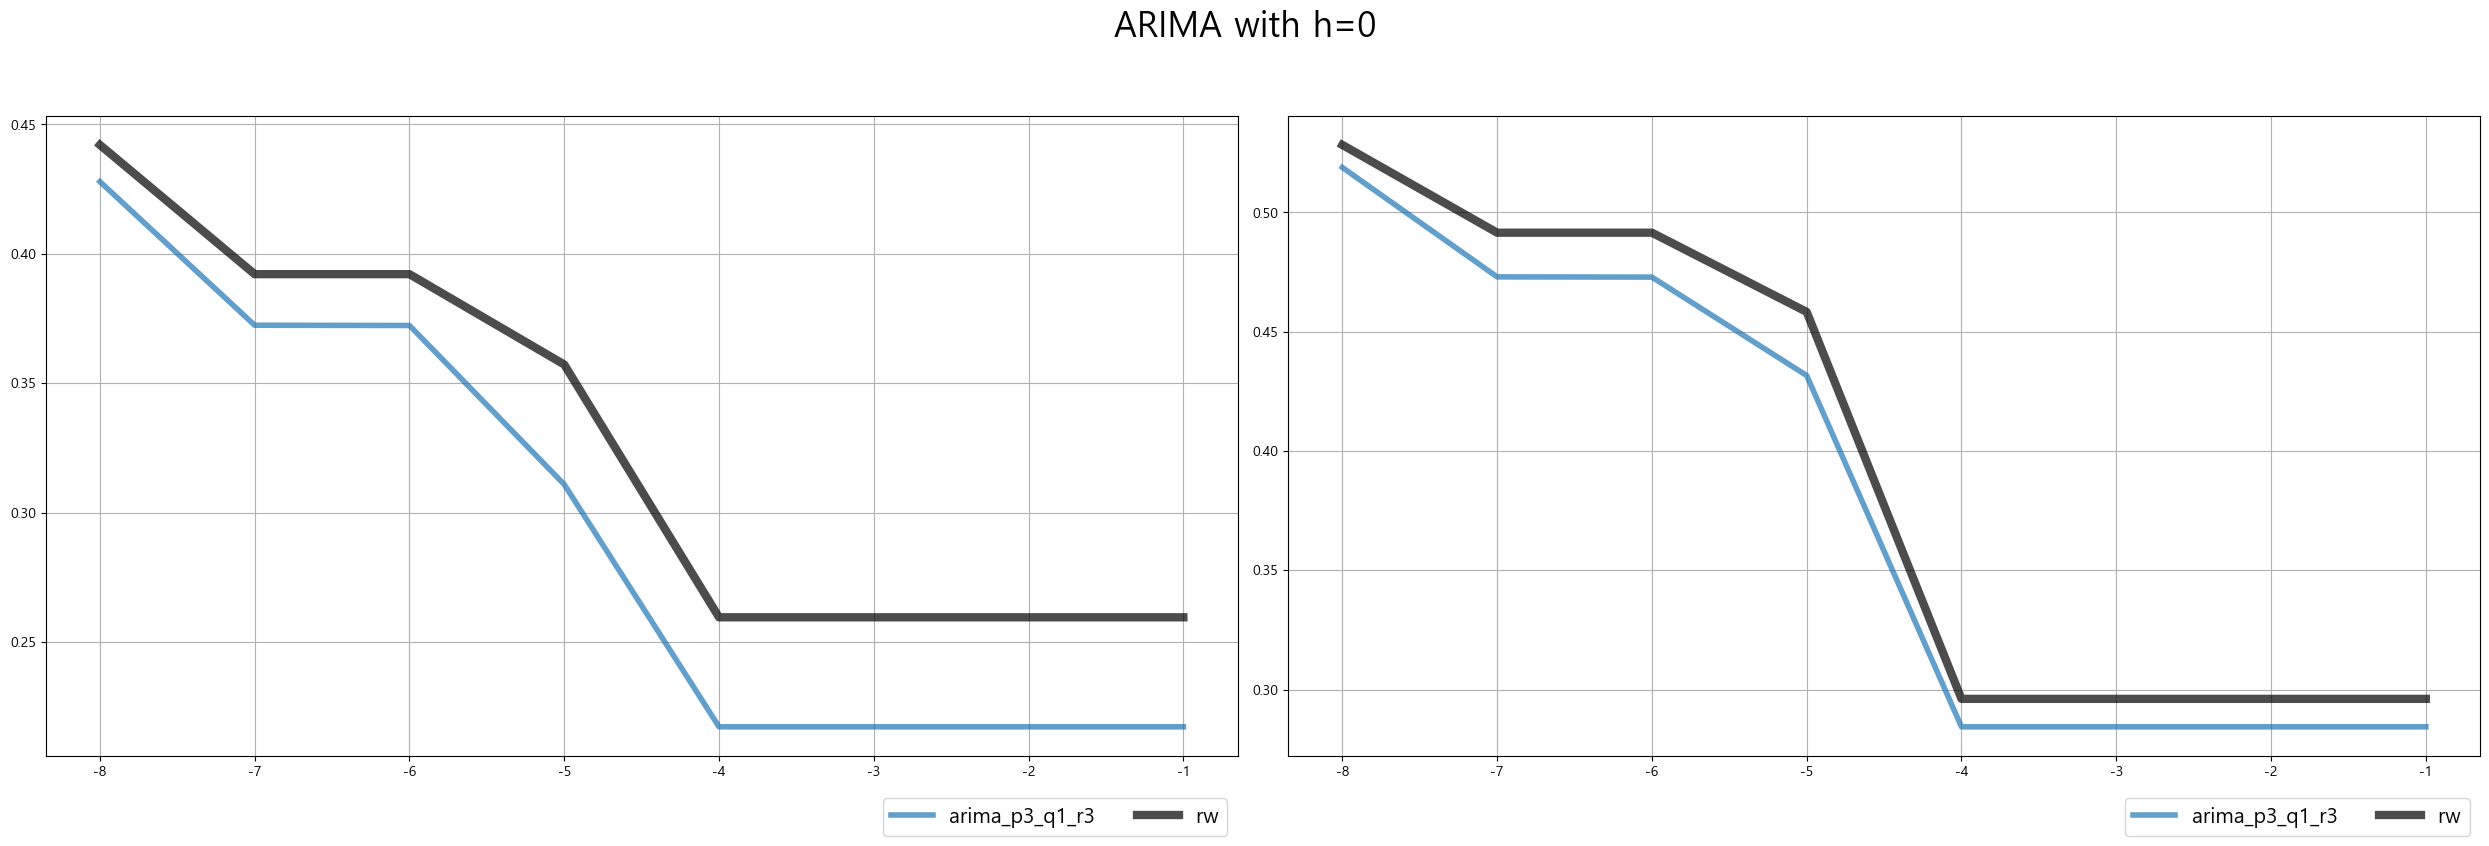

In [67]:
plot_mae_rmse(arima_mae, arima_rmse, rw_mae, rw_rmse, h=0, best=5, good=10, title='ARIMA',
              loc=1, ncol=4, figsize=(25, 8), fontsize=15, bbox_to_anchor=(1, -0.05))

(MAE) arima_p3_q1_r3: 0.536 
(RMSE) arima_p3_q1_r3: 0.642 
rw mae: 0.618 rw rmse: 0.711


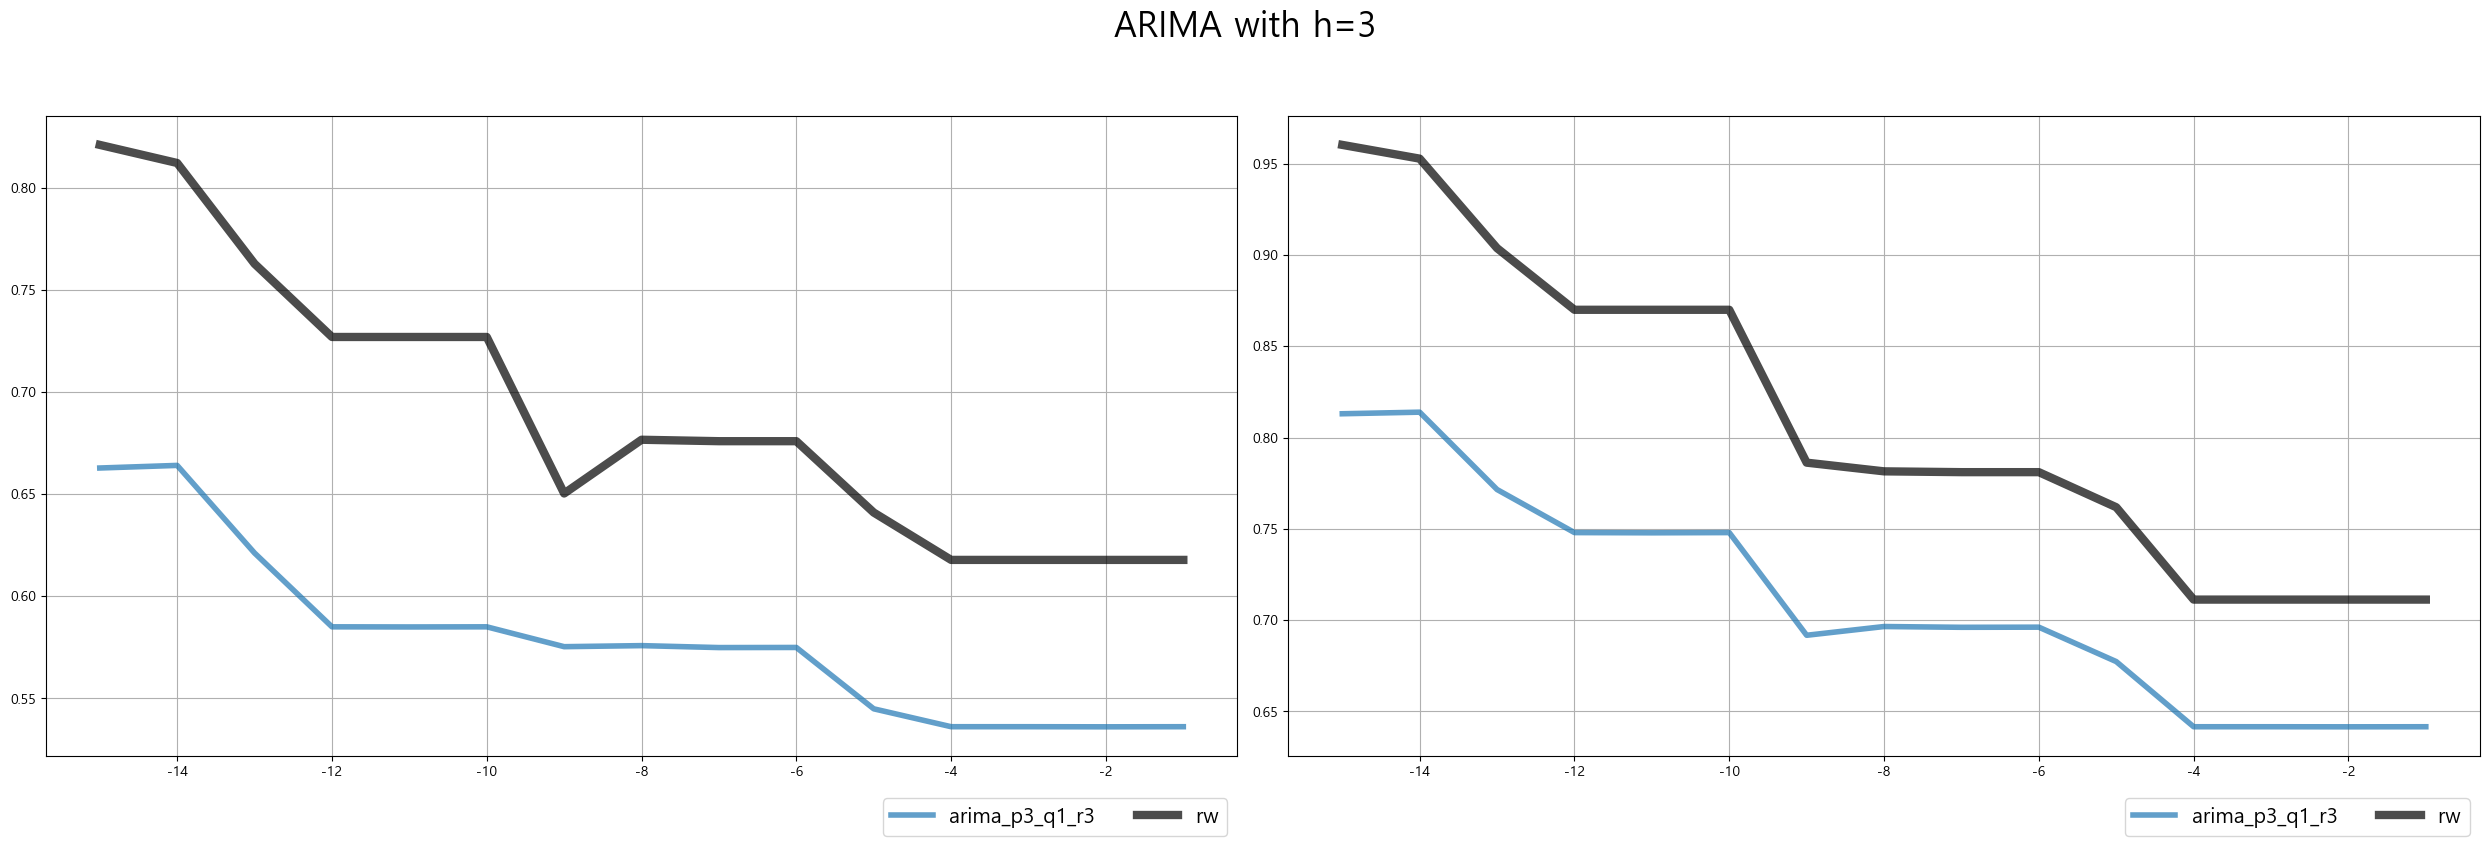

In [68]:
plot_mae_rmse(arima_mae, arima_rmse, rw_mae, rw_rmse, h=3, best=5, good=10, title='ARIMA',
              loc=1, ncol=4, figsize=(25, 8), fontsize=15, bbox_to_anchor=(1, -0.05))

(MAE) arima_p3_q1_r3: 0.757 
(RMSE) arima_p3_q1_r3: 0.884 
rw mae: 1.117 rw rmse: 1.290


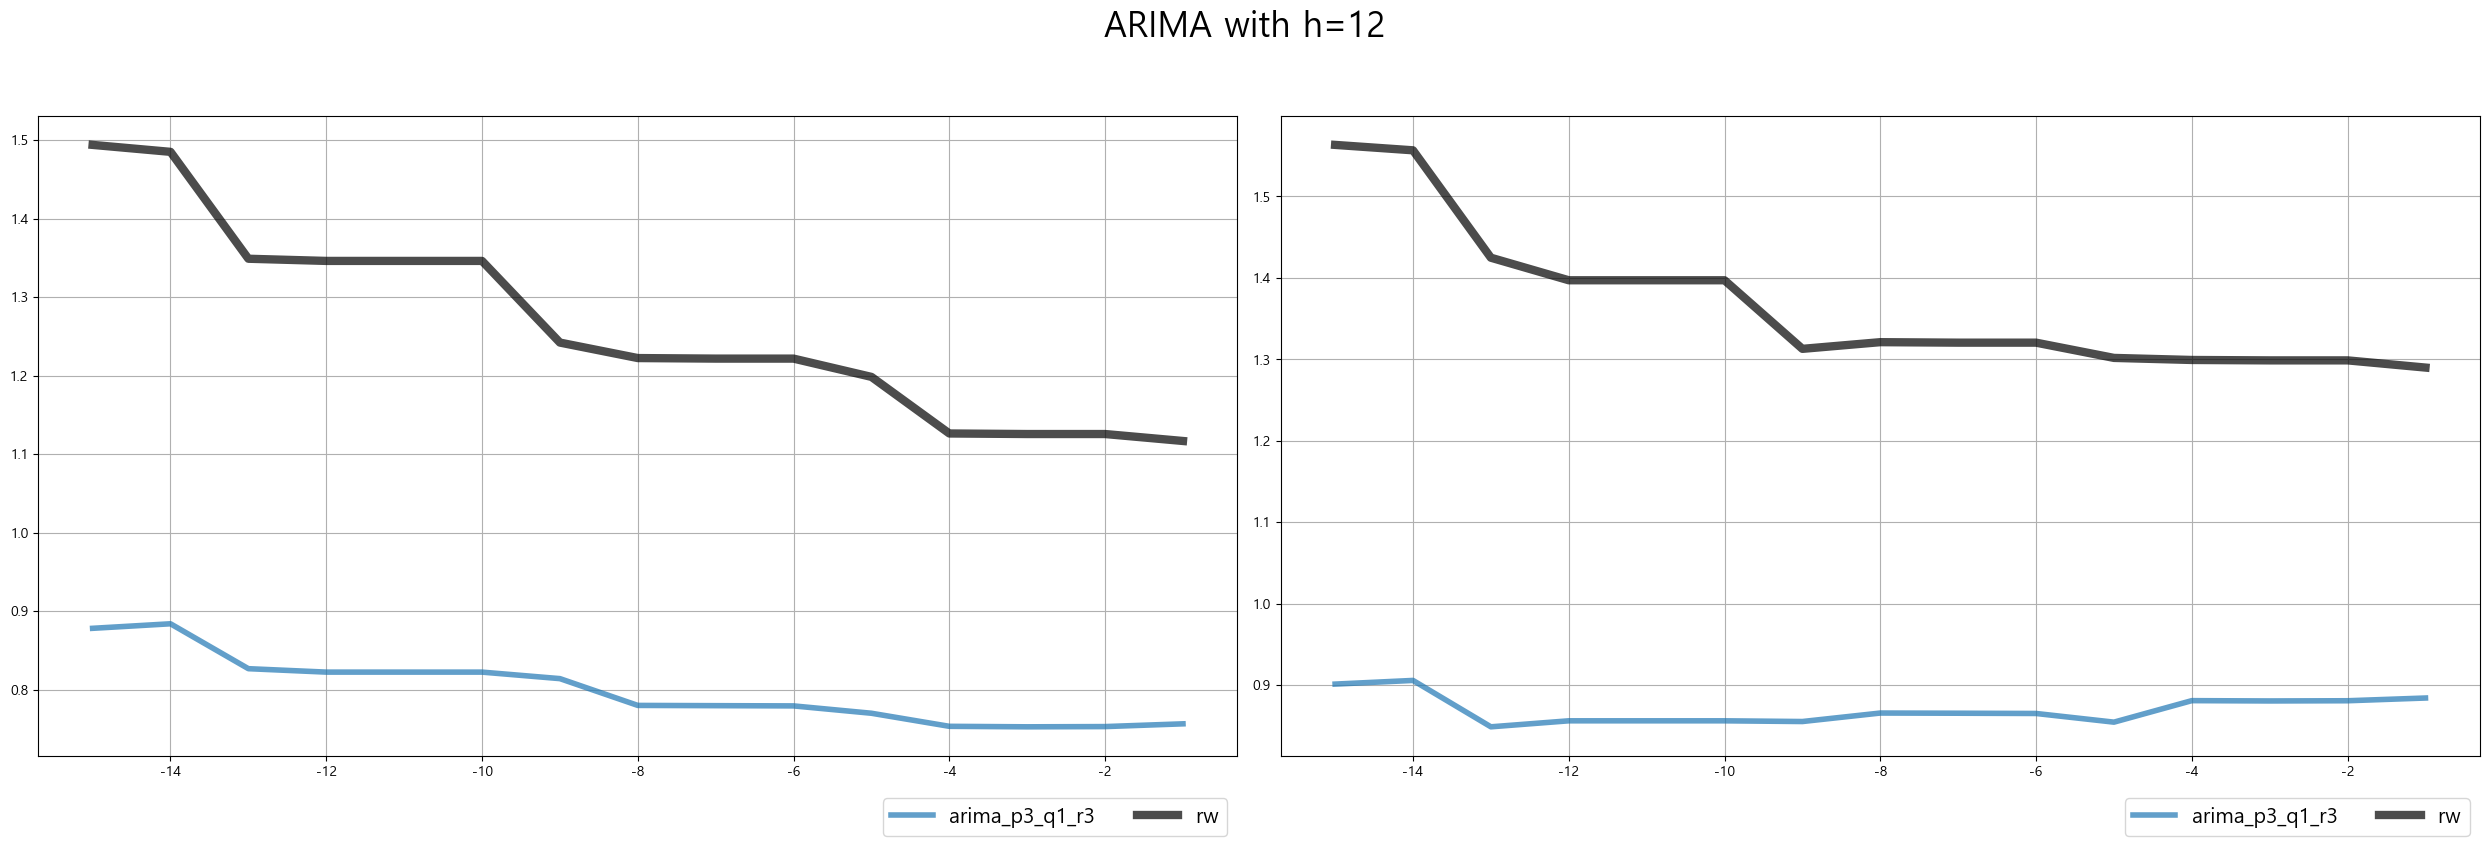

In [69]:
plot_mae_rmse(arima_mae, arima_rmse, rw_mae, rw_rmse, h=12, best=5, good=10, title='ARIMA',
              loc=1, ncol=4, figsize=(25, 8), fontsize=15, bbox_to_anchor=(1, -0.05))

## LM

(MAE) lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.204 lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.216 lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.219 lm_roll0_lag4_modelP_ipi_6-P_cpi_1-GB_cp_3_IN: 0.220 lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN: 0.222 
(RMSE) lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.247 lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.252 lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN: 0.254 lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.257 lm_roll0_lag4_modelP_ipi_6-P_cpi_1-GB_cp_3_IN: 0.261 
rw mae: 0.260 rw rmse: 0.296


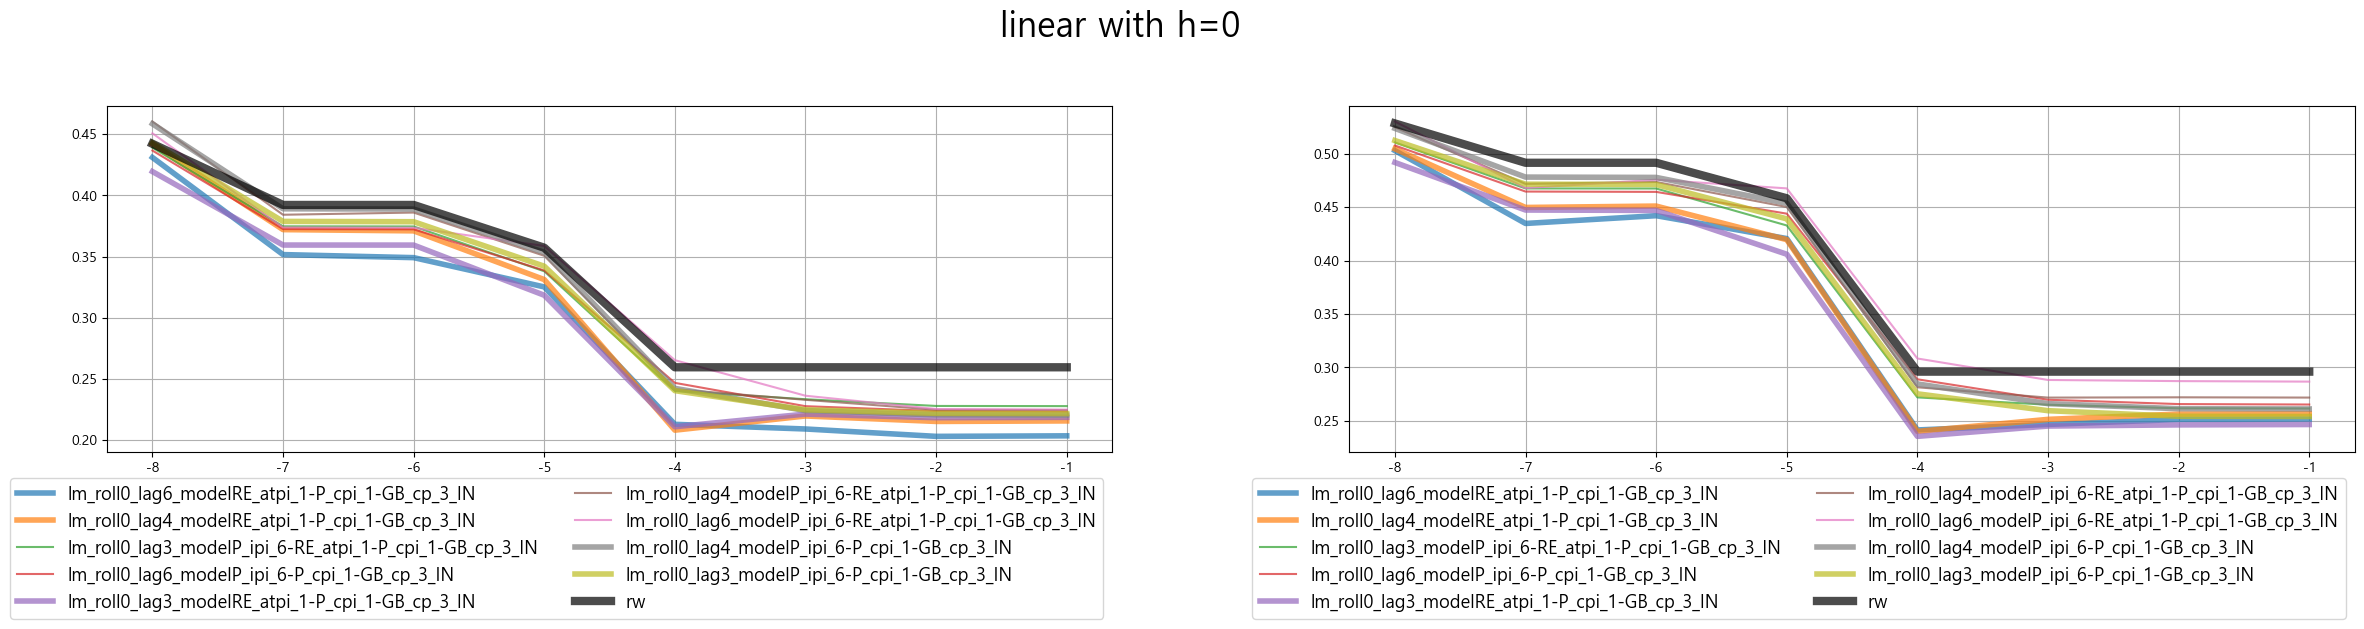

In [70]:
plot_mae_rmse(lm_mae, lm_rmse, rw_mae, rw_rmse, h=0, best=5, good=10, title='linear',
              loc=1, ncol=2, figsize=(25, 6), fontsize=13, bbox_to_anchor=(1, -0.05))

(MAE) lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.574 lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.581 lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.589 lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN: 0.610 lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.637 
(RMSE) lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.672 lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.676 lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.680 lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN: 0.724 lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN: 0.741 
rw mae: 0.618 rw rmse: 0.711


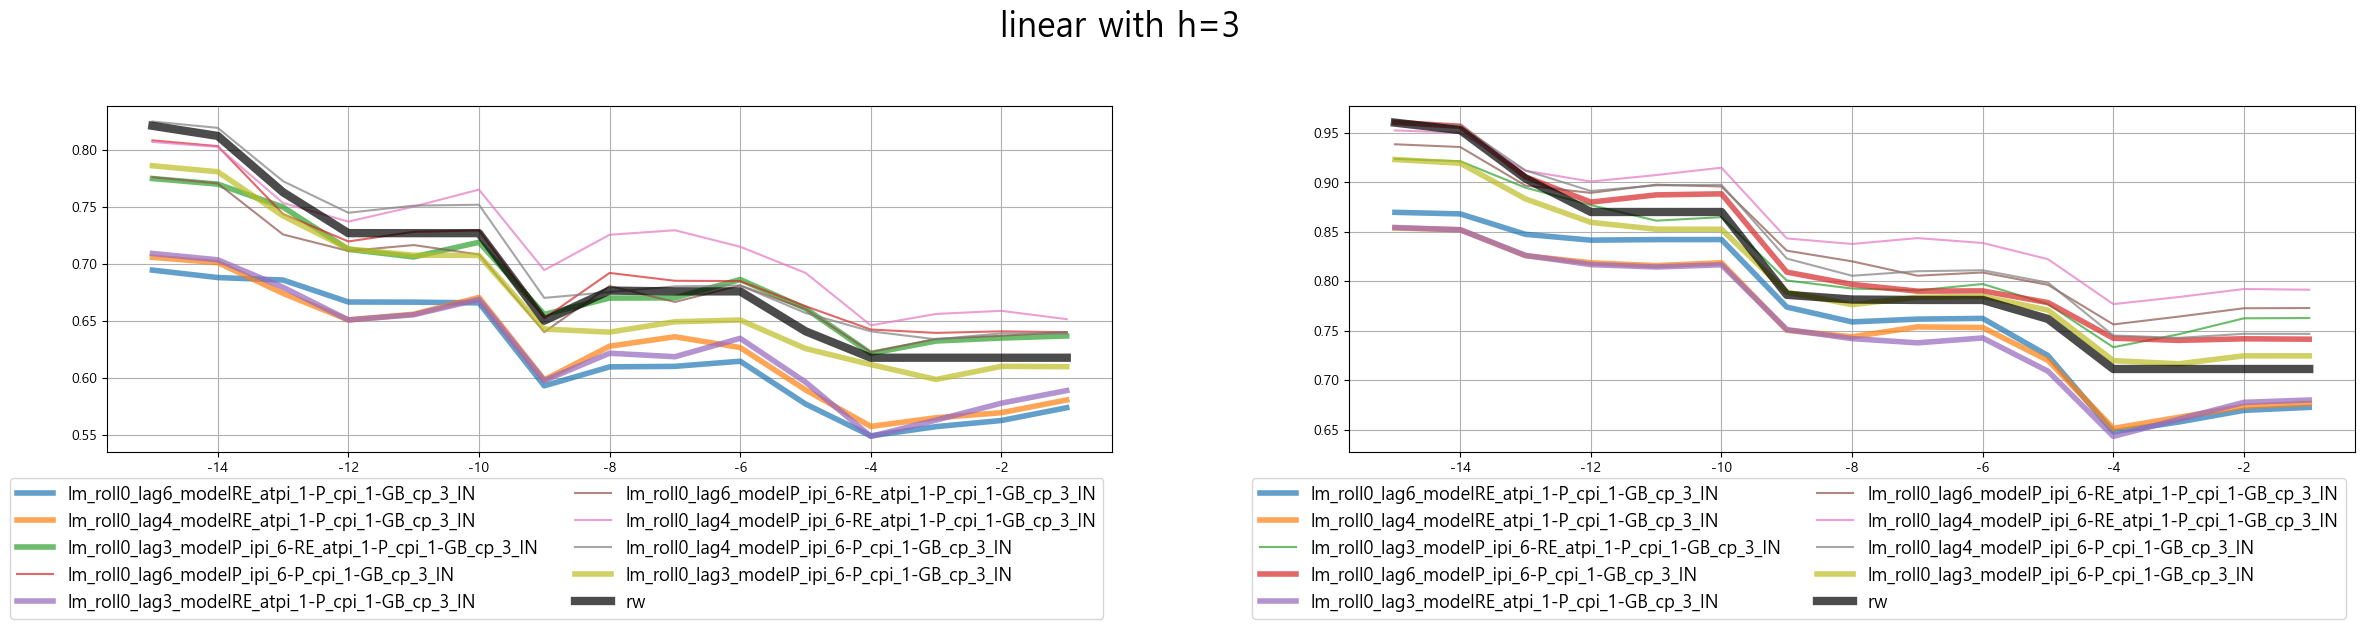

In [71]:
plot_mae_rmse(lm_mae, lm_rmse, rw_mae, rw_rmse, h=3, best=5, good=10, title='linear',
              loc=1, ncol=2, figsize=(25, 6), fontsize=13, bbox_to_anchor=(1, -0.05))

(MAE) lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN: 1.018 lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN: 1.075 lm_roll0_lag4_modelP_ipi_6-P_cpi_1-GB_cp_3_IN: 1.095 lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN: 1.147 lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN: 1.165 
(RMSE) lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN: 1.168 lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN: 1.224 lm_roll0_lag4_modelP_ipi_6-P_cpi_1-GB_cp_3_IN: 1.249 lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN: 1.450 lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN: 1.529 
rw mae: 1.117 rw rmse: 1.290


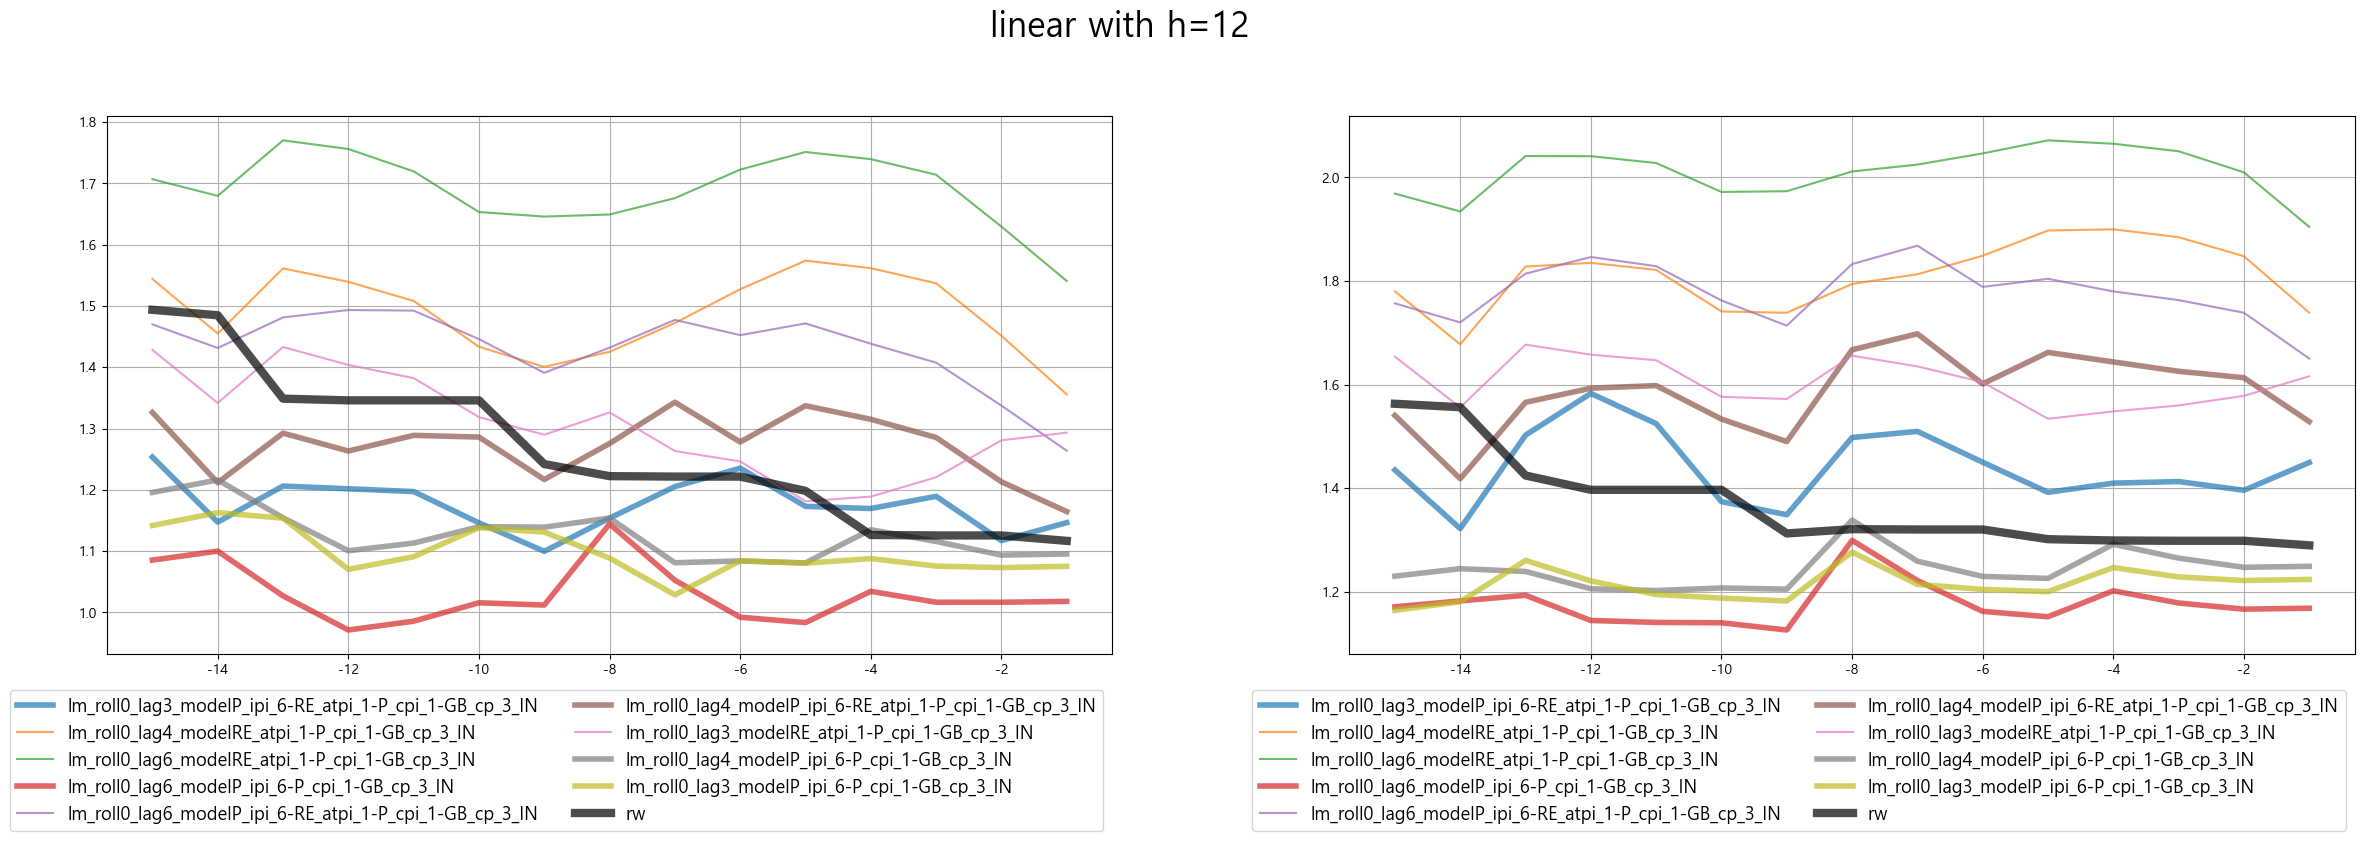

In [72]:
plot_mae_rmse(lm_mae, lm_rmse, rw_mae, rw_rmse, h=12, best=5, good=15, title='linear',
              loc=1, ncol=2, figsize=(25, 8), fontsize=13, bbox_to_anchor=(1, -0.05))

## EXT

(MAE) ext_roll0_lag0_d6_g1_IN: 0.184 
(RMSE) ext_roll0_lag0_d6_g1_IN: 0.212 
rw mae: 0.260 rw rmse: 0.296


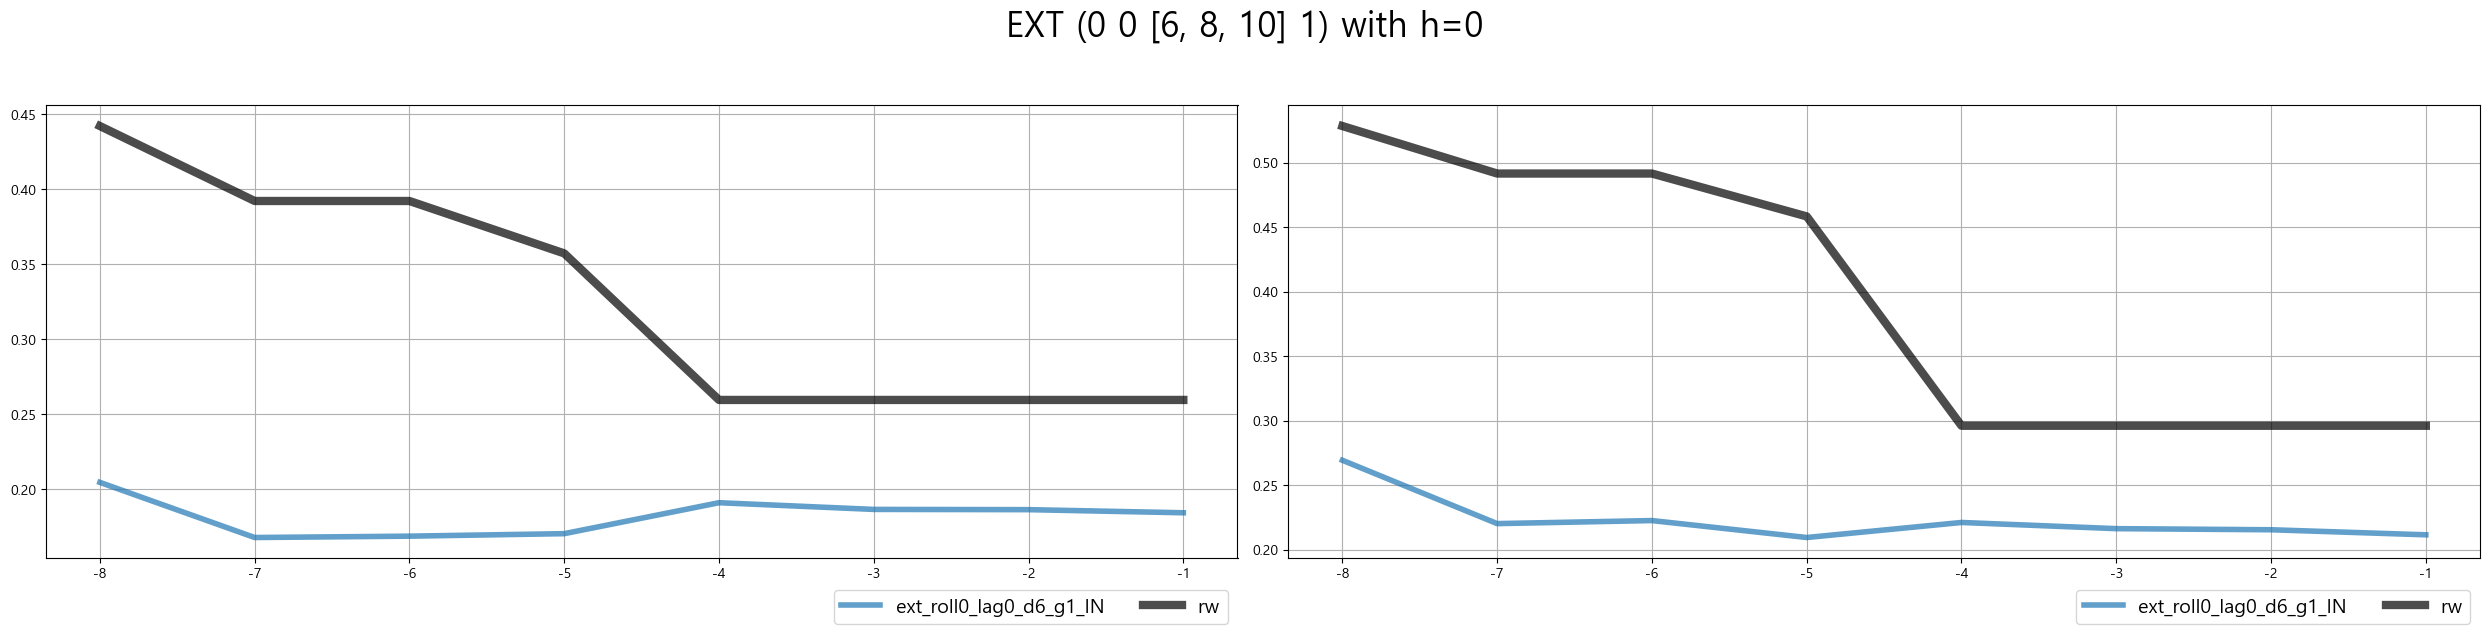

In [73]:
plot_mae_rmse(ext_mae, ext_rmse, rw_mae, rw_rmse, h=0, best=5, good=10, title='EXT (0 0 [6, 8, 10] 1)',
              loc=1, ncol=3, figsize=(25, 6), fontsize=14, bbox_to_anchor=(1, -0.05))

(MAE) ext_roll0_lag0_d6_g1_IN: 0.475 
(RMSE) ext_roll0_lag0_d6_g1_IN: 0.607 
rw mae: 0.618 rw rmse: 0.711


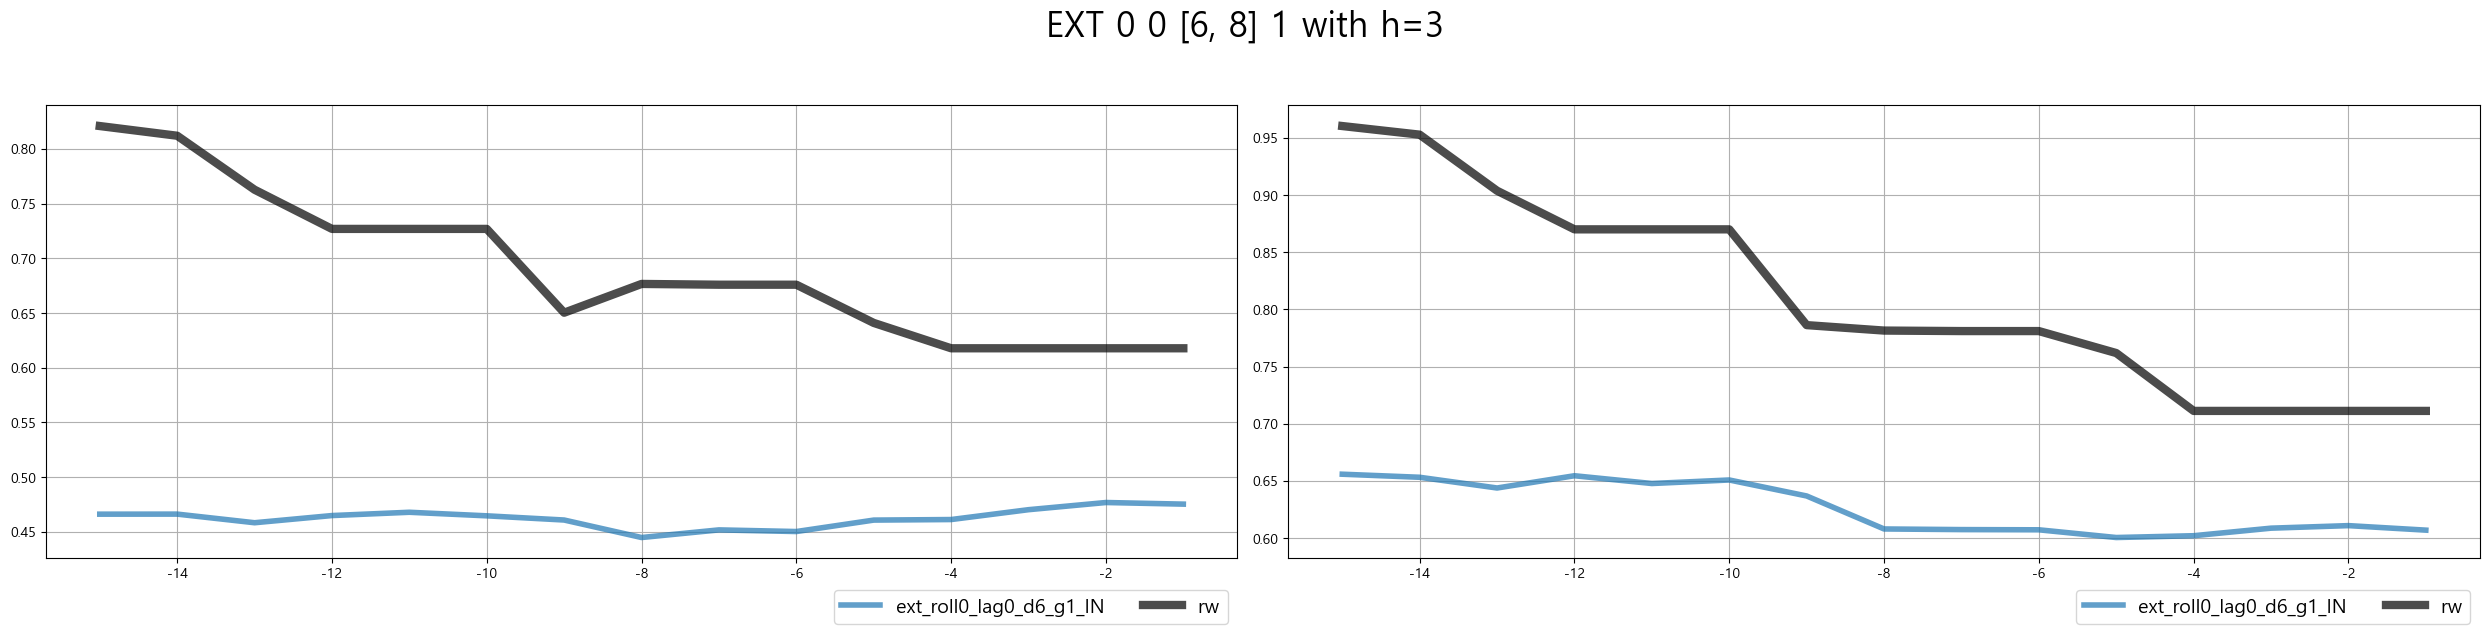

In [74]:
plot_mae_rmse(ext_mae, ext_rmse, rw_mae, rw_rmse, h=3, best=5, good=10, title='EXT 0 0 [6, 8] 1',
              loc=1, ncol=3, figsize=(25, 6), fontsize=14, bbox_to_anchor=(1, -0.05))

(MAE) ext_roll0_lag0_d6_g1_IN: 0.204 
(RMSE) ext_roll0_lag0_d6_g1_IN: 0.223 
rw mae: 1.117 rw rmse: 1.290


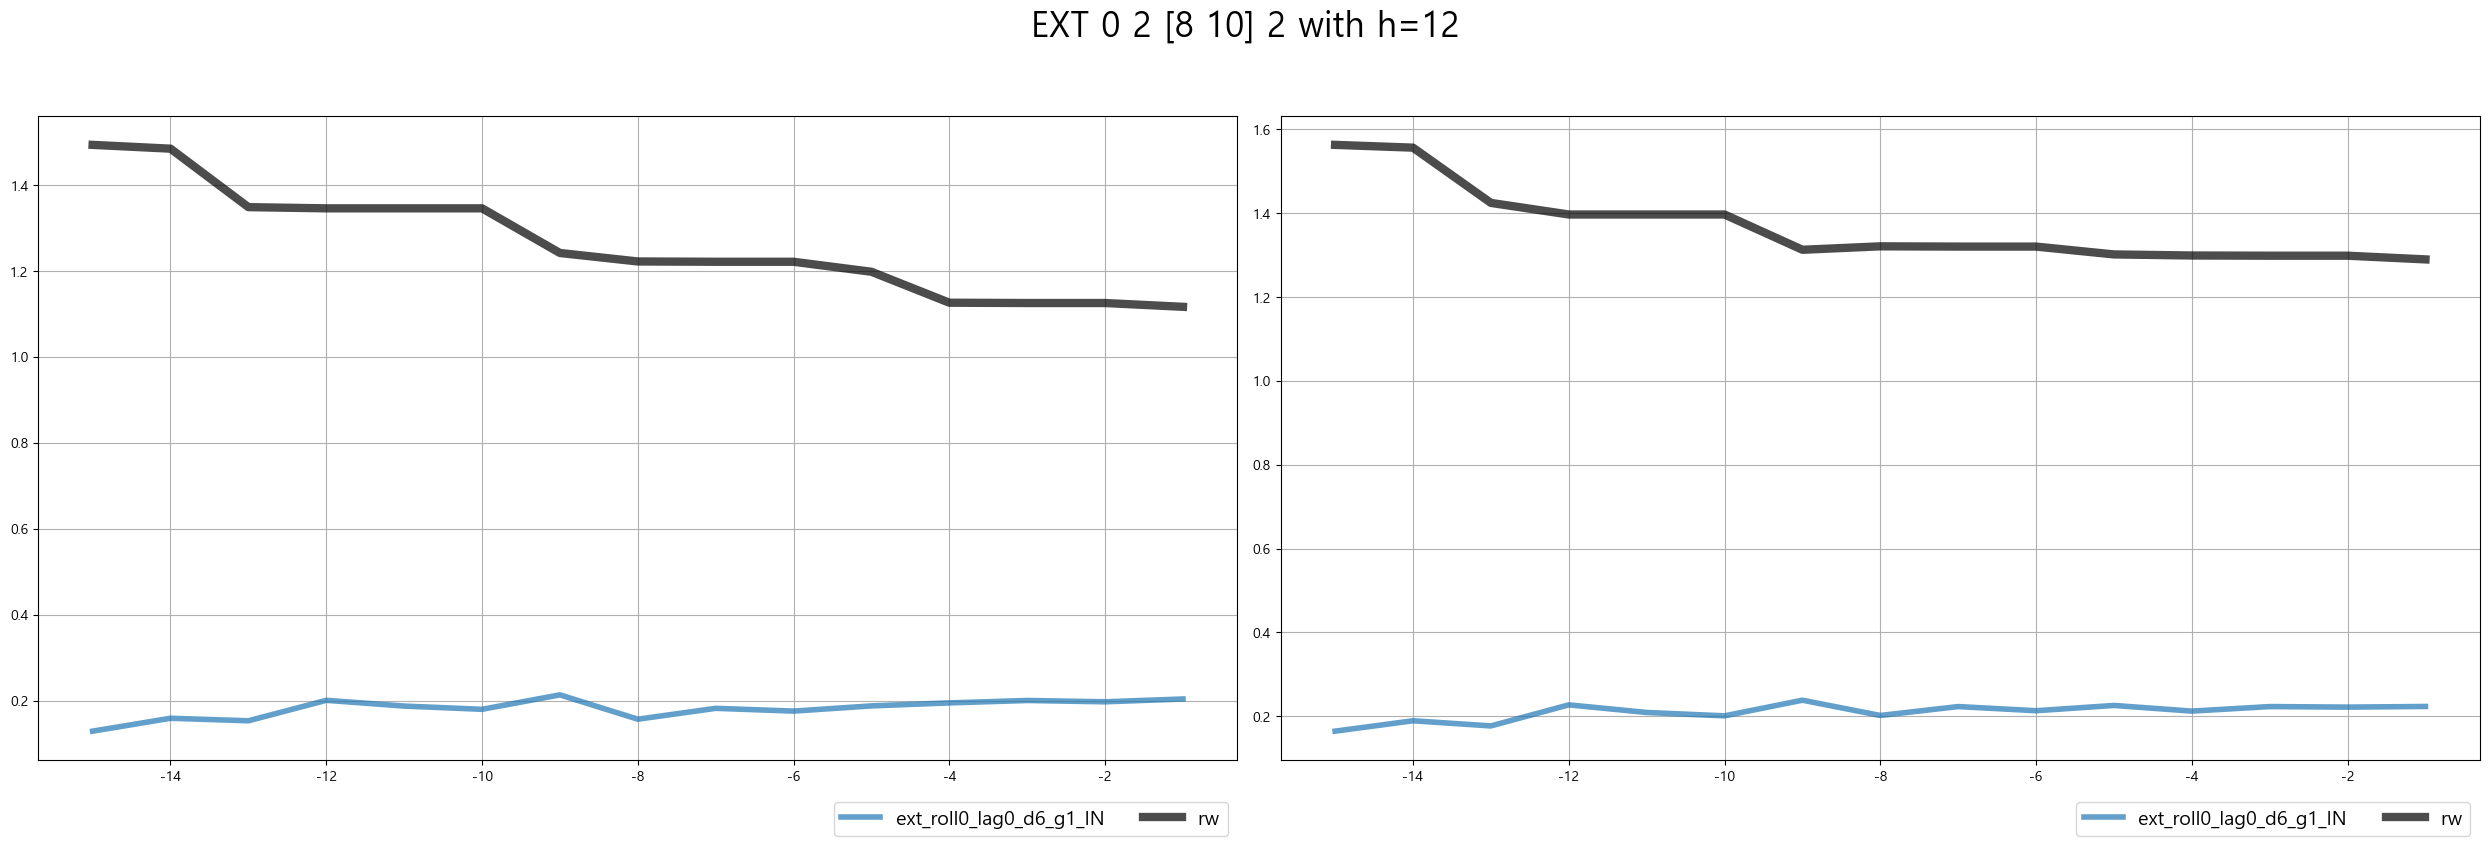

In [75]:
plot_mae_rmse(ext_mae, ext_rmse, rw_mae, rw_rmse, h=12, best=5, good=10, title='EXT 0 2 [8 10] 2',
              loc=1, ncol=3, figsize=(25, 8), fontsize=14, bbox_to_anchor=(1, -0.05))

## Ensemble

(MAE) ens49: 0.159 ens67: 0.159 ens64: 0.159 ens88: 0.159 ens85: 0.159 
(RMSE) ens113: 0.175 ens88: 0.176 ens119: 0.176 ens80: 0.177 ens39: 0.177 
rw mae: 0.260 rw rmse: 0.296


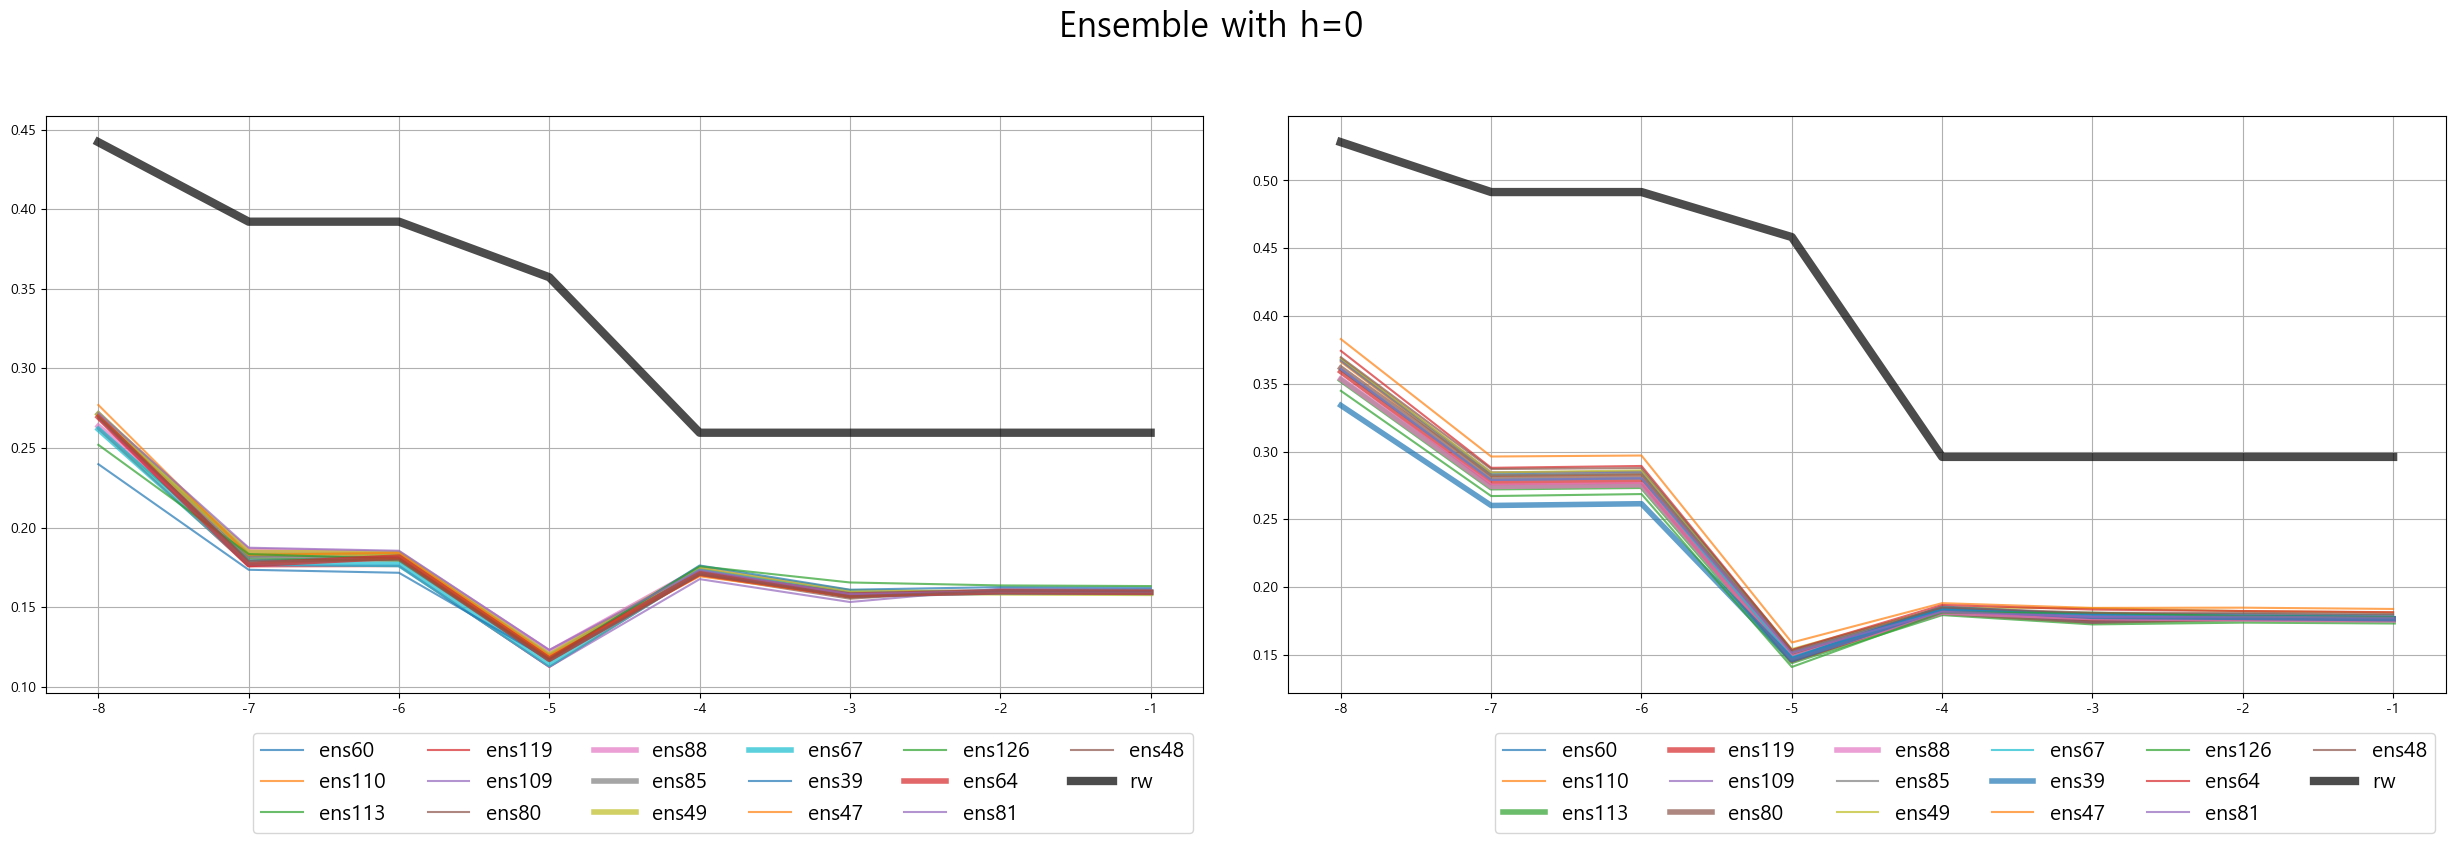

In [76]:
plot_mae_rmse(ens_mae, ens_rmse, rw_mae, rw_rmse, h=0, best=5, good=10, title='Ensemble',
              loc=1, ncol=6, figsize=(25, 8), fontsize=15, bbox_to_anchor=(1, -0.05))

In [77]:
#for i in [273, 685, 697, 541, 201, 695, 693, 217, 203]:
for i in [113, 88, 119, 80, 39]:
    print(i, '   '.join(ens_models[i]))

113 lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN   lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN   lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN   ext_roll0_lag0_d6_g1_IN
88 lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN   lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN   lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN   ext_roll0_lag0_d6_g1_IN
119 lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN   lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN   lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN   ext_roll0_lag0_d6_g1_IN
80 lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN   lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN   lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN   ext_roll0_lag0_d6_g1_IN
39 lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN   lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN   ext_roll0_lag0_d6_g1_IN


(MAE) ens94: 0.375 ens97: 0.382 ens111: 0.382 ens24: 0.382 ens112: 0.385 
(RMSE) ens97: 0.433 ens94: 0.439 ens101: 0.440 ens98: 0.443 ens111: 0.443 
rw mae: 0.618 rw rmse: 0.711


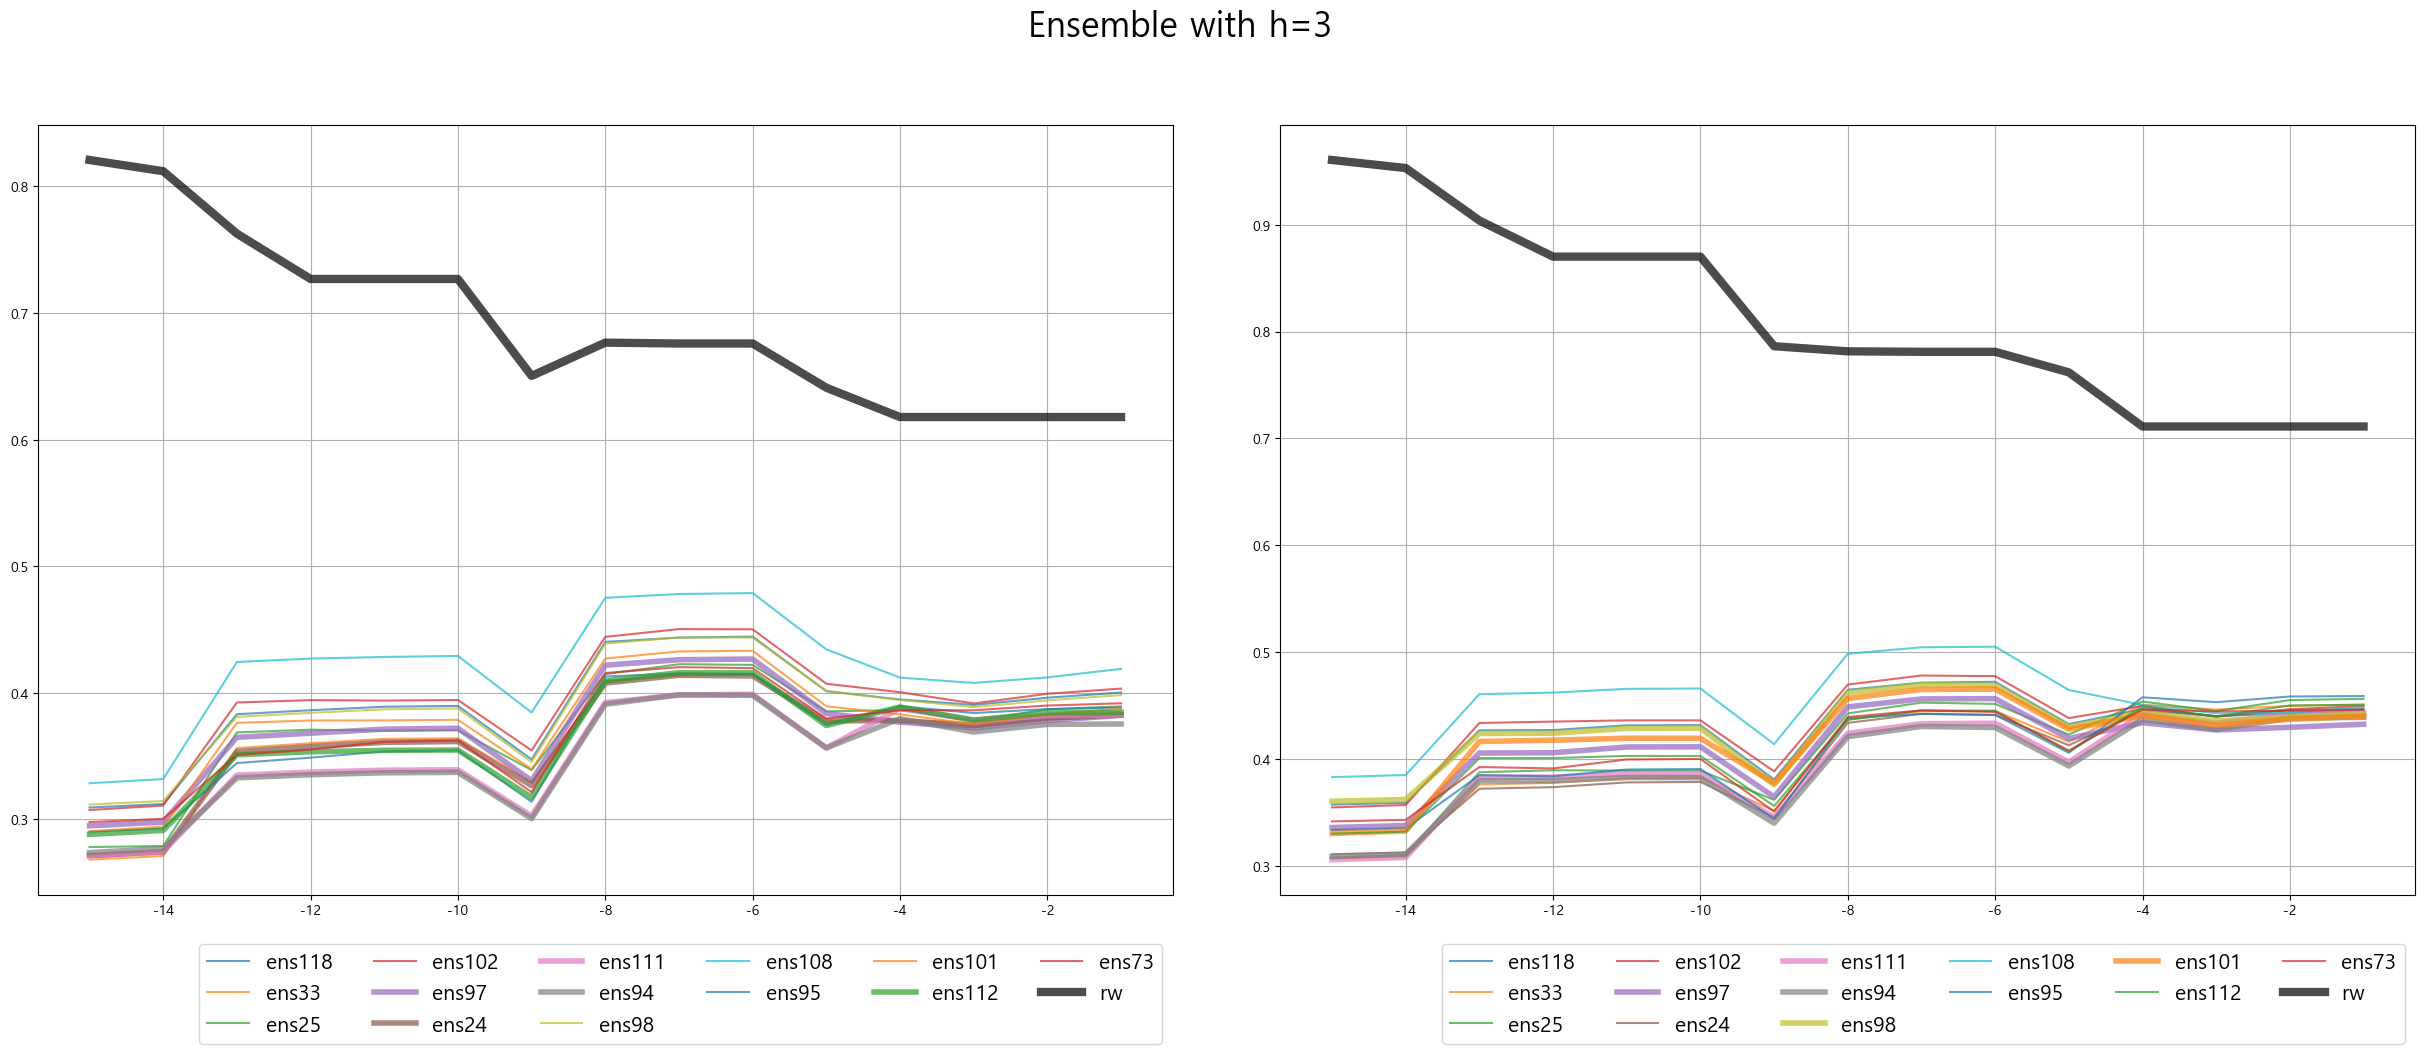

In [78]:
plot_mae_rmse(ens_mae, ens_rmse, rw_mae, rw_rmse, h=3, best=5, good=10, title='Ensemble',
              loc=1, ncol=6, figsize=(25, 10), fontsize=15, bbox_to_anchor=(1, -0.05), rw=True)

In [79]:
#for i in [113, 169, 17, 112, 168, 77, 372, 78, 374, 373]: # 324, 327, 1005, 326
for i in [97, 94, 101, 98, 111]:
    print( i, '    '.join(ens_models[i]))

97 lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    lm_roll0_lag4_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN
94 lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN
101 lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag4_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN
98 lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN
111 lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag4_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN


(MAE) ens43: 0.209 ens23: 0.219 ens44: 0.220 ens8: 0.223 ens92: 0.244 
(RMSE) ens8: 0.262 ens6: 0.287 ens43: 0.290 ens23: 0.296 ens105: 0.305 
rw mae: 1.117 rw rmse: 1.290


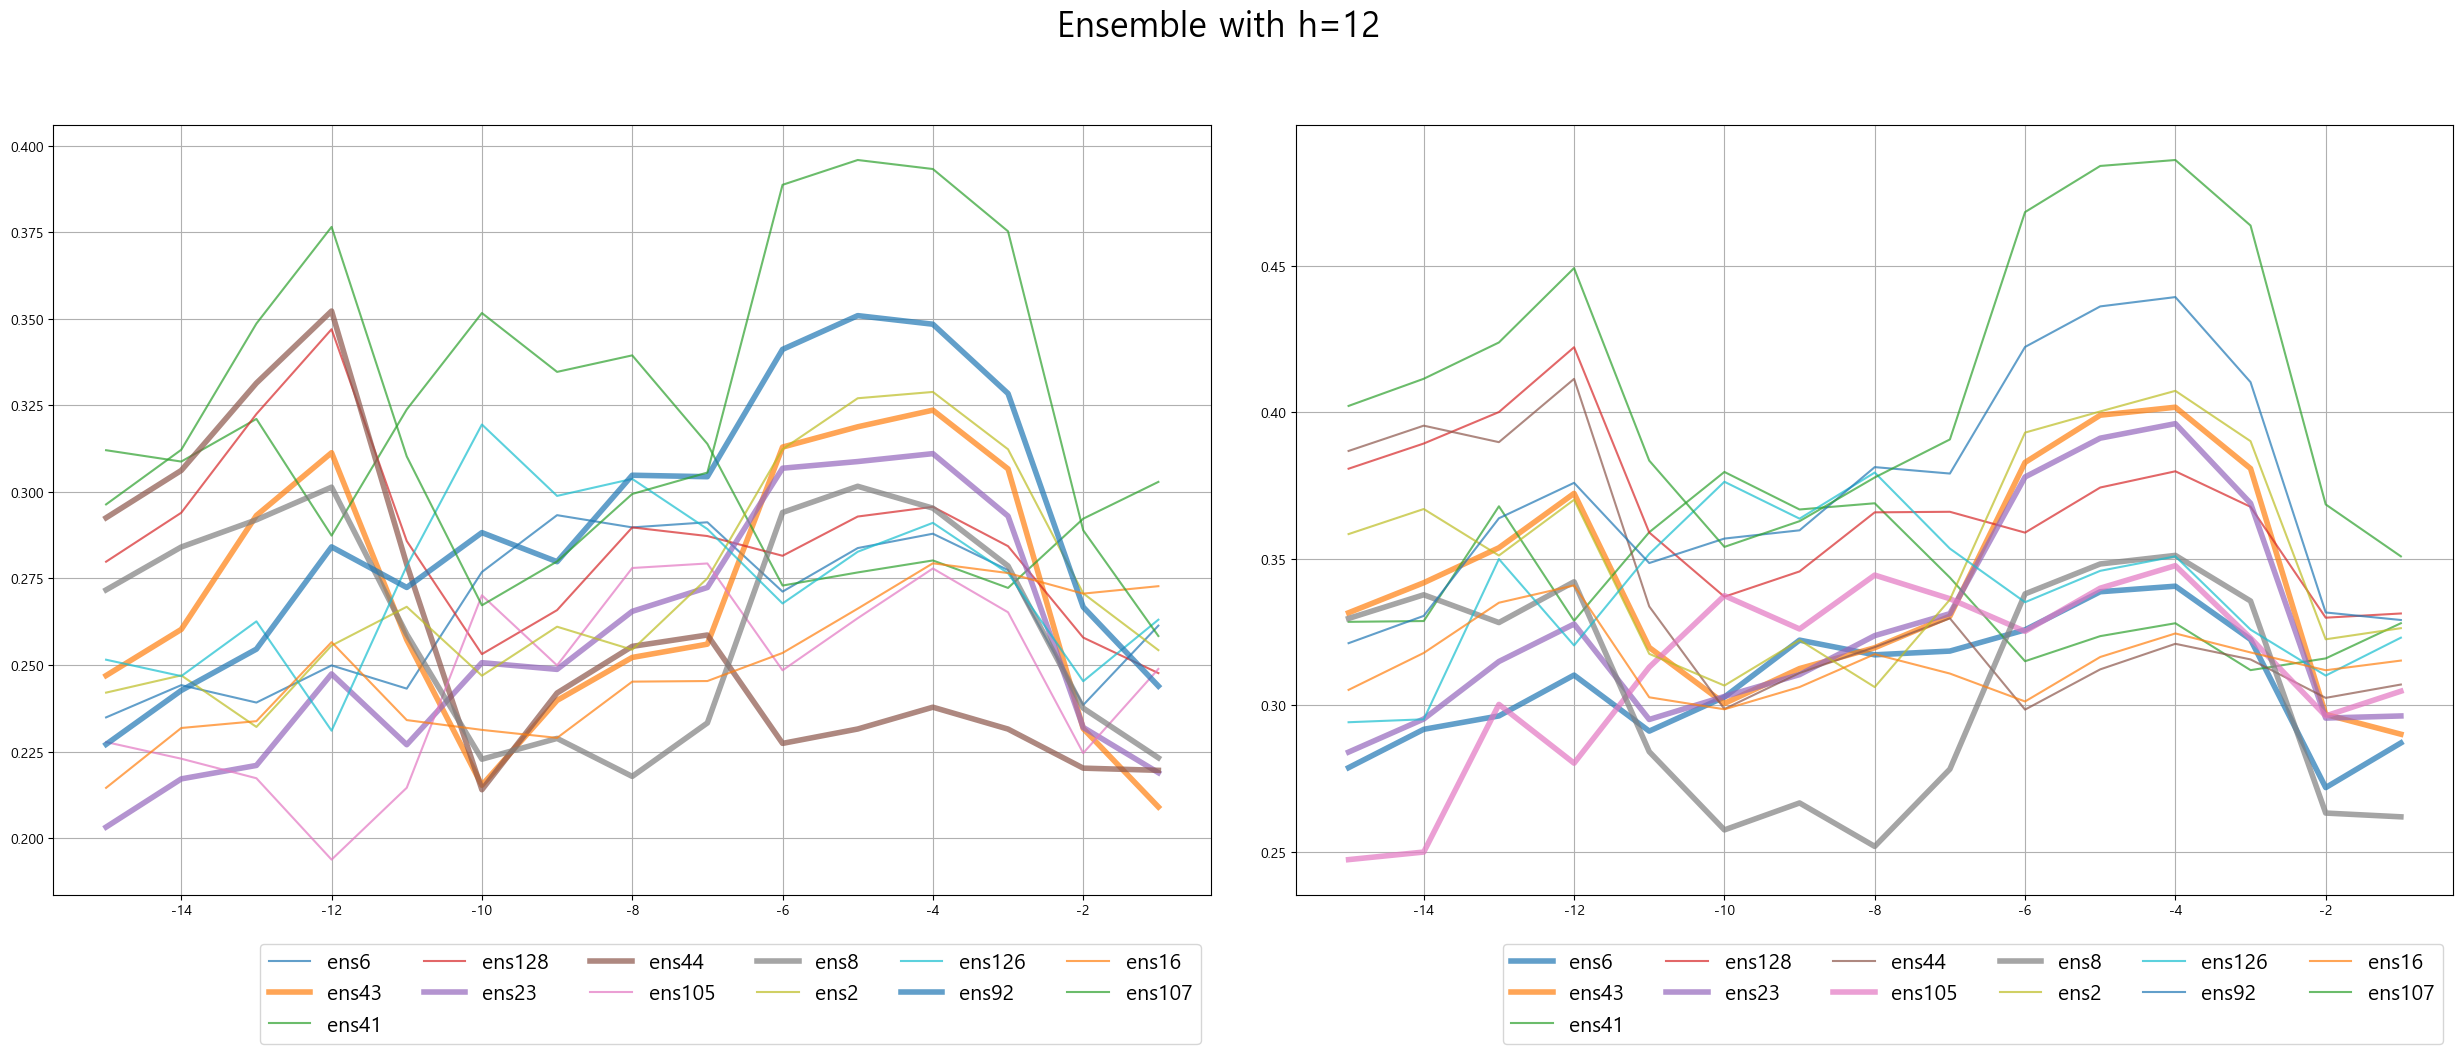

In [80]:
plot_mae_rmse(ens_mae, ens_rmse, rw_mae, rw_rmse, h=12, best=5, good=10, title='Ensemble',
              loc=1, ncol=6, figsize=(25, 10), fontsize=15, bbox_to_anchor=(1, -0.05), rw=False)

In [81]:
#for i in [21, 4, 5, 6, 7, 22]: # 8, 11, 9, 10,
for i in [8, 6, 4, 3, 23, 105]:
    print(i, '    '.join(ens_models[i]))

8 lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN
6 lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN
4 lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN
3 lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN
23 lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN
105 lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN


In [90]:
#ens_rmsef.iloc[:,-1].mean()/rw_rmse.iloc[:,-1].mean() #rmse ratio

# MDA

In [82]:
ens_pred = ens_pred.sort_index(axis=1)
lm_pred = lm_pred.sort_index(axis=1)
ext_pred = ext_pred.sort_index(axis=1)

In [ ]:
# tm16 = '2016-1-31'
# tm19 = '2019-1-31'
# tm20 = '2020-1-31'
# tm21 = '2021-1-31'
# tm22 = '2022-1-31'
# tm99 = '2023-9-30'

In [83]:
tm25 = '2025-1-31'

In [84]:
act.loc[rw_pred_last.index]

2024-05-31    2.672546
2024-06-30    2.410939
2024-07-31    2.551891
2024-08-31    2.012825
2024-09-30    1.595038
2024-10-31    1.253642
2024-11-30    1.526447
2024-12-31    1.933824
2025-01-31    2.244411
2025-02-28    2.021445
2025-03-31    2.053532
2025-04-30    2.078765
2025-05-31    1.901840
Name: P_cpi_1, dtype: float64

In [86]:
#for h in [0, 3, 12]:
for h in [0]:
    matched, mda, mda, p1, p2 = get_mda(rw_pred_last.loc[tm25:, h], act, h, print_result=True)

mda: 0.00 (0/4), mda_big: 0.00 (0/1, 0.21) 


In [87]:
#arima_models = ['arima_p2_q1_r3', 'arima_p3_q1_r3']
arima_models = ['arima_p3_q1_r3']
#for h in [0, 3, 12]:
for h in [0]:
    #mae, rmse, pred_last = get_eval_last_pred(arima_pred.loc[:, idx[arima_models, :, :tm25]], arima_models, act)
    mae, rmse, pred_last = get_eval_last_pred(arima_pred.loc[:, idx[arima_models, :, tm25:]], arima_models, act)
    best = mae[h].loc[-1].sort_values().iloc[:1].index.tolist()
    best += rmse[h].loc[-1].sort_values().iloc[:1].index.tolist()
    best = list(set(best))
    for i in best:
        matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=True)

  0%|          | 0/1 [00:00<?, ?it/s]

mda: 0.75 (3/4), mda_big: 1.00 (1/1, 0.21) arima_p3_q1_r3


## h = 0

In [88]:
ens_mae[0].loc[-1].sort_values().iloc[:10].index.tolist()

['ens49',
 'ens67',
 'ens64',
 'ens88',
 'ens85',
 'ens60',
 'ens81',
 'ens48',
 'ens47',
 'ens119']

In [89]:
models = ['ens' + str(i) for i in [49, 67, 64, 88, 85, 60, 81, 48, 47, 119]]

for i in [int(m[3:]) for m in models]:
   print(i, '    '.join(ens_models[i]))

49 lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN
67 lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN
64 lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN
88 lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN
85 lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN
60 lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_c

In [90]:
models = ['ens' + str(i) for i in [49]]

for i in [int(m[3:]) for m in models]:
    print(i, '    '.join(ens_models[i]))

49 lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN


In [91]:
h=0
# M0 = tm16
# M1 = tm21
M0 = tm25
M1 = '2025-05-31'
topN = 10

mae, rmse, pred_last = get_eval_last_pred(ens_pred.loc[:, idx[models, :, M0:M1]], models, act)
best = mae[h].loc[-1].sort_values().iloc[:topN].index.tolist()
best += rmse[h].loc[-1].sort_values().iloc[:topN].index.tolist()
best = list(set(best))
print(f"{M0} - {M1}")
for i in best:
    matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
    print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")


mae, rmse, pred_last = get_eval_last_pred(lm_pred.loc[:, idx[lm_best_for_ensemble, :, M0:M1]], lm_best_for_ensemble, act)
best = mae[h].loc[-1].sort_values().iloc[:topN].index.tolist()
best += rmse[h].loc[-1].sort_values().iloc[:topN].index.tolist()
best = list(set(best))
print(f"{M0} - {M1}")
for i in best:
    matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
    print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

# M0 = tm21
# M1 = tm99
# mae, rmse, pred_last = get_eval_last_pred(ens_pred.loc[:, idx[models, :, M0:M1]], models, act)
# best = mae[h].loc[-1].sort_values().iloc[:topN].index.tolist()
# best += rmse[h].loc[-1].sort_values().iloc[:topN].index.tolist()
# best = list(set(best))
# print(f"{M0} - {M1}")
# for i in best:
#     matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
#     print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

# mae, rmse, pred_last = get_eval_last_pred(lm_pred.loc[:, idx[lm_best_for_ensemble, :, M0:M1]], lm_best_for_ensemble, act)
# best = mae[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best += rmse[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best = list(set(best))
# print(f"{M0} - {M1}")
# for i in best:
#     matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
#     print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")
# M0 = tm16
# M1 = tm99
# mae, rmse, pred_last = get_eval_last_pred(ens_pred.loc[:, idx[models, :, M0:M1]], models, act)
# best = mae[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best += rmse[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best = list(set(best))
# print(f"{M0} - {M1}")
# for i in best:
#     matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
#     print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

# mae, rmse, pred_last = get_eval_last_pred(lm_pred.loc[:, idx[lm_best_for_ensemble, :, M0:M1]], lm_best_for_ensemble, act)
# best = mae[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best += rmse[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best = list(set(best))
# print(f"{M0} - {M1}")
# for i in best:
#     matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
#     print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

  0%|          | 0/1 [00:00<?, ?it/s]

2025-1-31 - 2025-05-31
mae: 0.168, rmse: 0.188 mda: 0.50 (2/4) mda_big: 1.00 (1/1, 0.21) model: ens49


  0%|          | 0/9 [00:00<?, ?it/s]

2025-1-31 - 2025-05-31
mae: 0.158, rmse: 0.185 mda: 0.50 (2/4) mda_big: 1.00 (1/1, 0.21) model: lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN
mae: 0.168, rmse: 0.197 mda: 0.50 (2/4) mda_big: 1.00 (1/1, 0.21) model: lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN
mae: 0.170, rmse: 0.201 mda: 0.50 (2/4) mda_big: 1.00 (1/1, 0.21) model: lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN
mae: 0.155, rmse: 0.171 mda: 0.50 (2/4) mda_big: 1.00 (1/1, 0.21) model: lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN
mae: 0.151, rmse: 0.169 mda: 0.50 (2/4) mda_big: 1.00 (1/1, 0.21) model: lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN
mae: 0.154, rmse: 0.178 mda: 0.50 (2/4) mda_big: 1.00 (1/1, 0.21) model: lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN
mae: 0.168, rmse: 0.192 mda: 0.50 (2/4) mda_big: 1.00 (1/1, 0.21) model: lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN
mae: 0.156, rmse: 0.171 mda: 0.50 (2/4) mda_big: 1.00 (1/1, 0.21) model: lm_roll0_lag4_modelP_ipi_6-P_cpi_1-

## h = 3

In [92]:
ens_mae[3].loc[-1].sort_values().iloc[:10].index.tolist()

['ens94',
 'ens97',
 'ens111',
 'ens24',
 'ens112',
 'ens33',
 'ens101',
 'ens95',
 'ens25',
 'ens73']

In [93]:
ens_models[94]

['lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN',
 'lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN',
 'lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN',
 'ext_roll0_lag0_d6_g1_IN']

In [94]:
models = ['ens' + str(i) for i in [94]]

for i in [int(m[3:]) for m in models]:
    print(i, '    '.join(ens_models[i]))

94 lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN


In [95]:
mae, rmse, pred_last = get_eval_last_pred(ens_pred.loc[:, idx[models, :, M0:M1]], models, act)

  0%|          | 0/1 [00:00<?, ?it/s]

In [96]:
h=3
# M0 = tm16
# M1 = tm21
M0 = tm25
M1 = '2025-05-31'
topN = 10

mae, rmse, pred_last = get_eval_last_pred(ens_pred.loc[:, idx[models, :, M0:M1]], models, act)
best = mae[h].loc[-1].sort_values().iloc[:topN].index.tolist()
best += rmse[h].loc[-1].sort_values().iloc[:topN].index.tolist()
best = list(set(best))
print(f"{M0} - {M1}")
for i in best:
    matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
    print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

mae, rmse, pred_last = get_eval_last_pred(lm_pred.loc[:, idx[lm_best_for_ensemble, :, M0:M1]], lm_best_for_ensemble, act)
best = mae[h].loc[-1].sort_values().iloc[:topN].index.tolist()
best += rmse[h].loc[-1].sort_values().iloc[:topN].index.tolist()
best = list(set(best))
print(f"{M0} - {M1}")
for i in best:
    matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
    print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

# M0 = tm21
# M1 = tm99
# mae, rmse, pred_last = get_eval_last_pred(ens_pred.loc[:, idx[models, :, M0:M1]], models, act)
# best = mae[h].loc[-1].sort_values().iloc[:topN].index.tolist()
# best += rmse[h].loc[-1].sort_values().iloc[:topN].index.tolist()
# best = list(set(best))
# print(f"{M0} - {M1}")
# for i in best:
#     matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
#     print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

# mae, rmse, pred_last = get_eval_last_pred(lm_pred.loc[:, idx[lm_best_for_ensemble, :, M0:M1]], lm_best_for_ensemble, act)
# best = mae[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best += rmse[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best = list(set(best))
# print(f"{M0} - {M1}")
# for i in best:
#     matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
#     print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

# M0 = tm16
# M1 = tm99
# mae, rmse, pred_last = get_eval_last_pred(ens_pred.loc[:, idx[models, :, M0:M1]], models, act)
# best = mae[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best += rmse[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best = list(set(best))
# print(f"{M0} - {M1}")
# for i in best:
#     matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
#     print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

# mae, rmse, pred_last = get_eval_last_pred(lm_pred.loc[:, idx[lm_best_for_ensemble, :, M0:M1]], lm_best_for_ensemble, act)
# best = mae[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best += rmse[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best = list(set(best))
# print(f"{M0} - {M1}")
# for i in best:
#     matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
#     print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

  0%|          | 0/1 [00:00<?, ?it/s]

2025-1-31 - 2025-05-31
mae: 0.432, rmse: 0.493 mda: 0.75 (3/4) mda_big: 1.00 (2/2, 0.45) model: ens94


  0%|          | 0/9 [00:00<?, ?it/s]

2025-1-31 - 2025-05-31
mae: 0.383, rmse: 0.401 mda: 0.75 (3/4) mda_big: 1.00 (2/2, 0.45) model: lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN
mae: 0.452, rmse: 0.463 mda: 0.50 (2/4) mda_big: 0.50 (1/2, 0.45) model: lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN
mae: 0.458, rmse: 0.513 mda: 0.50 (2/4) mda_big: 0.50 (1/2, 0.45) model: lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN
mae: 0.469, rmse: 0.514 mda: 0.75 (3/4) mda_big: 1.00 (2/2, 0.45) model: lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN
mae: 0.390, rmse: 0.416 mda: 0.50 (2/4) mda_big: 0.50 (1/2, 0.45) model: lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN
mae: 0.430, rmse: 0.471 mda: 0.50 (2/4) mda_big: 0.50 (1/2, 0.45) model: lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN
mae: 0.474, rmse: 0.519 mda: 0.50 (2/4) mda_big: 0.50 (1/2, 0.45) model: lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN
mae: 0.389, rmse: 0.412 mda: 0.75 (3/4) mda_big: 1.00 (2/2, 0.45) model: lm_roll0_lag4_modelP_ipi_6-P_cpi_1-

## h = 12

In [97]:
ens_mae[12].loc[-1].sort_values().iloc[:10].index.tolist()

['ens43',
 'ens23',
 'ens44',
 'ens8',
 'ens92',
 'ens128',
 'ens105',
 'ens2',
 'ens107',
 'ens6']

In [98]:
ens_models[43]

['lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN',
 'lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN',
 'ext_roll0_lag0_d6_g1_IN']

In [99]:
models = ['ens' + str(i) for i in [43]]

for i in [int(m[3:]) for m in models]:
    print(i, '    '.join(ens_models[i]))

43 lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN


In [100]:
h=12
# M0 = tm16
# M1 = tm21
M0 = tm25
M1 = '2025-05-31'
topN = 10

mae, rmse, pred_last = get_eval_last_pred(ens_pred.loc[:, idx[models, :, M0:M1]], models, act)
best = mae[h].loc[-1].sort_values().iloc[:topN].index.tolist()
best += rmse[h].loc[-1].sort_values().iloc[:topN].index.tolist()
best = list(set(best))
print(f"{M0} - {M1}")
for i in best:
    matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
    print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

mae, rmse, pred_last = get_eval_last_pred(lm_pred.loc[:, idx[lm_best_for_ensemble, :, M0:M1]], lm_best_for_ensemble, act)
best = mae[h].loc[-1].sort_values().iloc[:topN].index.tolist()
best += rmse[h].loc[-1].sort_values().iloc[:topN].index.tolist()
best = list(set(best))
print(f"{M0} - {M1}")
for i in best:
    matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
    print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

# M0 = tm21
# M1 = tm99
# mae, rmse, pred_last = get_eval_last_pred(ens_pred.loc[:, idx[models, :, M0:M1]], models, act)
# best = mae[h].loc[-1].sort_values().iloc[:topN].index.tolist()
# best += rmse[h].loc[-1].sort_values().iloc[:topN].index.tolist()
# best = list(set(best))
# print(f"{M0} - {M1}")
# for i in best:
#     matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
#     print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

# mae, rmse, pred_last = get_eval_last_pred(lm_pred.loc[:, idx[lm_best_for_ensemble, :, M0:M1]], lm_best_for_ensemble, act)
# best = mae[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best += rmse[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best = list(set(best))
# print(f"{M0} - {M1}")
# for i in best:
#     matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
#     print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")
# M0 = tm16
# M1 = tm99
# mae, rmse, pred_last = get_eval_last_pred(ens_pred.loc[:, idx[models, :, M0:M1]], models, act)
# best = mae[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best += rmse[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best = list(set(best))
# print(f"{M0} - {M1}")
# for i in best:
#     matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
#     print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

# mae, rmse, pred_last = get_eval_last_pred(lm_pred.loc[:, idx[lm_best_for_ensemble, :, M0:M1]], lm_best_for_ensemble, act)
# best = mae[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best += rmse[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best = list(set(best))
# print(f"{M0} - {M1}")
# for i in best:
#     matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
#     print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

  0%|          | 0/1 [00:00<?, ?it/s]

2025-1-31 - 2025-05-31
mae: 0.437, rmse: 0.479 mda: 1.00 (4/4) mda_big: 1.00 (4/4, 0.11) model: ens43


  0%|          | 0/9 [00:00<?, ?it/s]

2025-1-31 - 2025-05-31
mae: 0.487, rmse: 0.592 mda: 1.00 (4/4) mda_big: 1.00 (4/4, 0.11) model: lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN
mae: 0.527, rmse: 0.534 mda: 1.00 (4/4) mda_big: 1.00 (4/4, 0.11) model: lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN
mae: 0.746, rmse: 0.871 mda: 0.50 (2/4) mda_big: 0.50 (2/4, 0.11) model: lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN
mae: 1.145, rmse: 1.147 mda: 0.25 (1/4) mda_big: 0.25 (1/4, 0.11) model: lm_roll0_lag4_modelP_ipi_6-P_cpi_1-GB_cp_3_IN
mae: 1.141, rmse: 1.153 mda: 0.50 (2/4) mda_big: 0.50 (2/4, 0.11) model: lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN
mae: 0.557, rmse: 0.611 mda: 1.00 (4/4) mda_big: 1.00 (4/4, 0.11) model: lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN
mae: 0.558, rmse: 0.687 mda: 0.75 (3/4) mda_big: 0.75 (3/4, 0.11) model: lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN
mae: 0.351, rmse: 0.458 mda: 1.00 (4/4) mda_big: 1.00 (4/4, 0.11) model: lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-

## MDA plot

In [103]:
MATCHED = {}

# M0 = tm16
# M1 = tm99
M0 = tm25
M1 = '2025-05-31'

for h, model in zip([0, 3, 12], ['ens49', 'ens94', 'ens43']):
    mae, rmse, pred_last = get_eval_last_pred(ens_pred.loc[:, idx[[model], :, M0:M1]], [model], act)
    matched, mda, mda, p1, p2 = get_mda(pred_last[h][model], act, h, model=model, print_result=False)

    df = matched.to_frame('m')
    df['i'] = 0
    df.loc[df.m.eq(False), 'i'] = 1
    df['c'] = df['i'].cumsum()
    df = df.loc[df.m == True]
    df['date'] = df.index
    df = pd.concat([df.groupby('c')['date'].first().to_frame('first'), df.groupby('c')['date'].last().to_frame('last')], axis=1)
    df.index.names = [None]
    MATCHED[h] = df

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

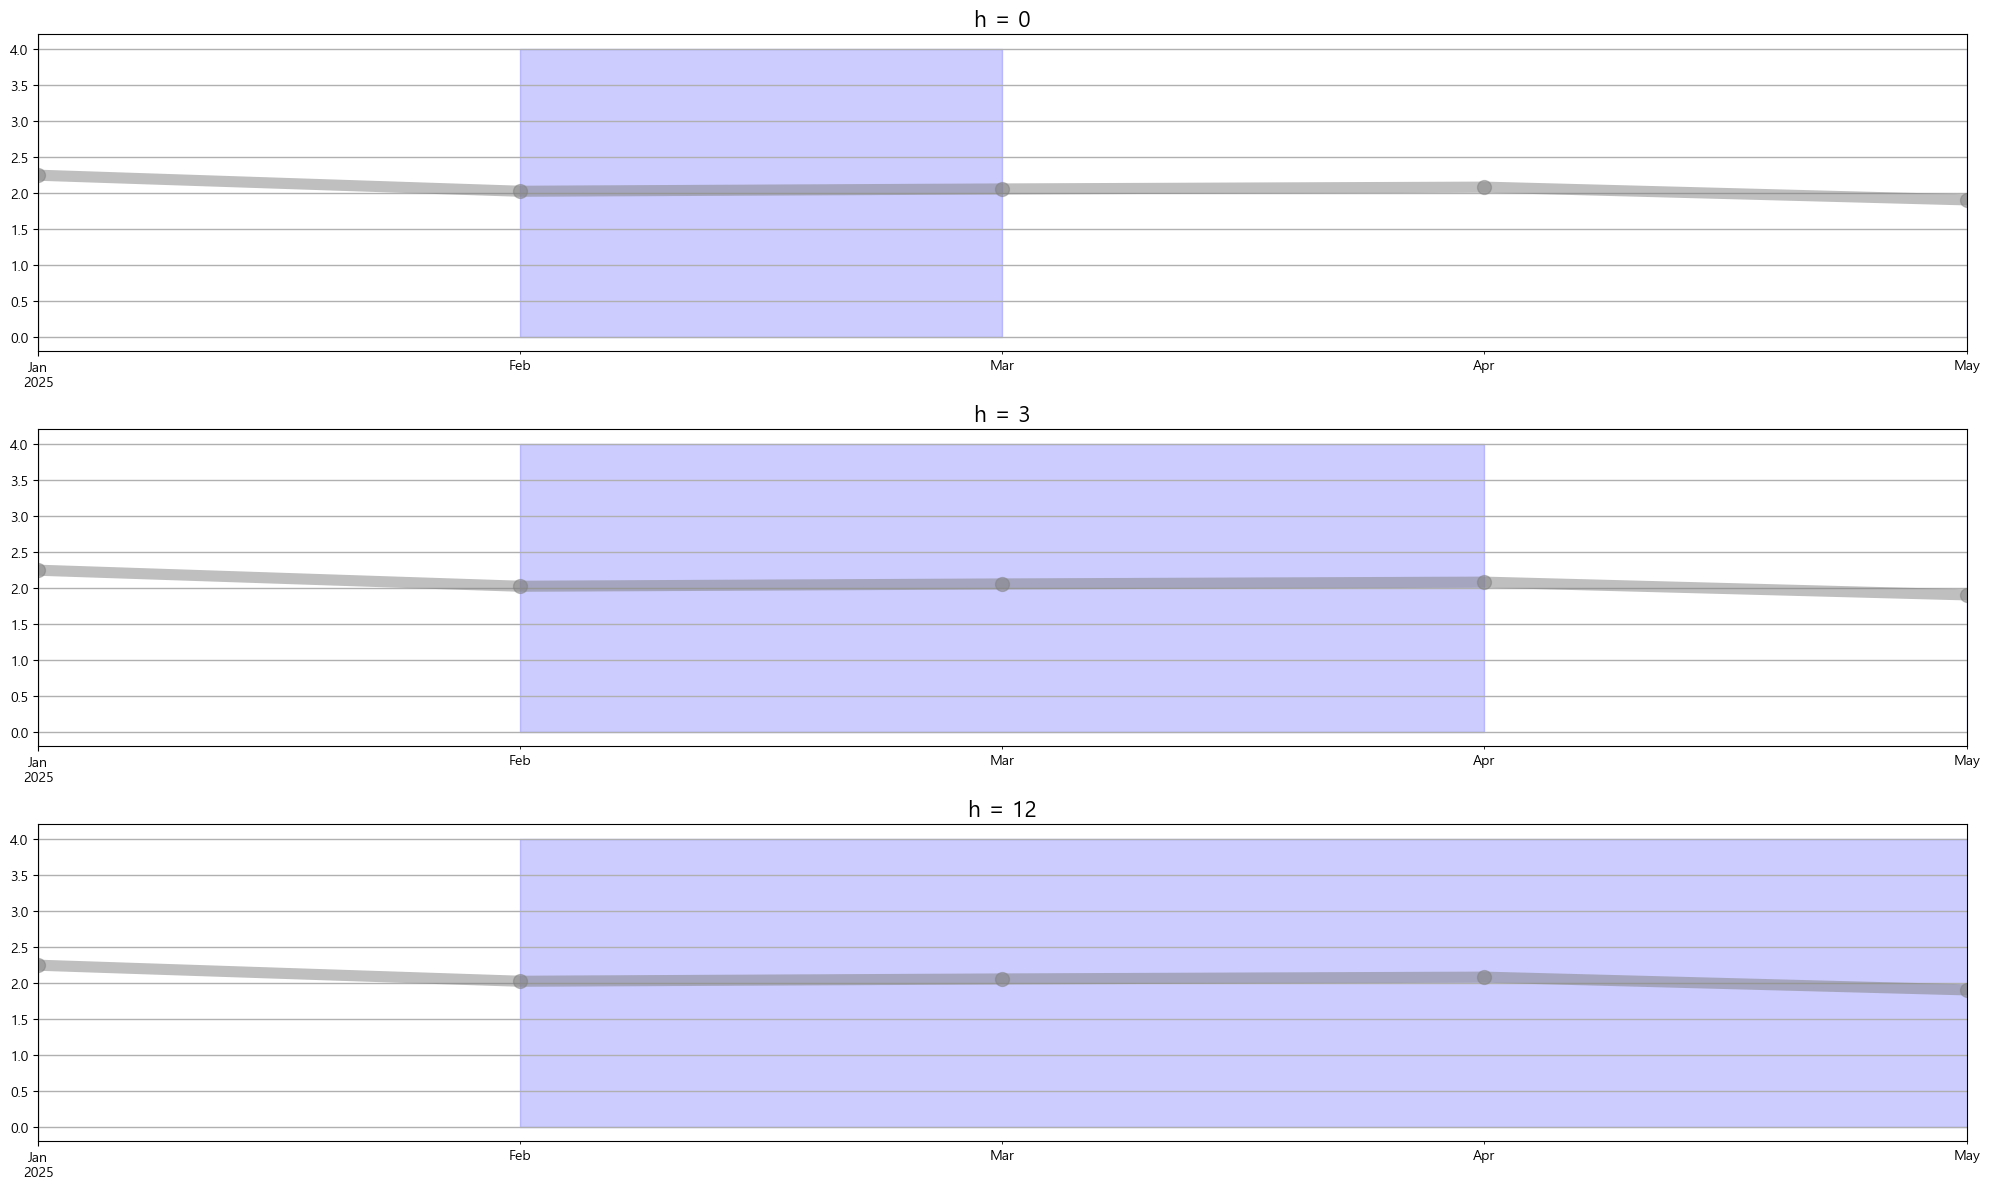

In [104]:
fig, axs = plt.subplots(3, 1, figsize=(20, 12))
for ax, h in zip(axs, [0, 3, 12]):
    act[targets].loc['2025':].plot(ax=ax, lw=8, color='gray', marker='o', markersize=10, alpha=0.5)
    ax.grid(which='major', lw=1)
    #ax.legend(fontsize=14)
    ax.set_title(f"h = {h}", fontsize=16)

    for ix, row in MATCHED[h].iterrows(): # iterrows: 행 인덱스와 행 데이터를 모두 반환
        m0 = row['first']
        m1 = row['last'] + MonthEnd(1)
        #m0 = nth_friday(m0.year, m0.month, -2)
        #m1 = nth_friday(m1.year, m1.month, 2)
        ax.fill_between(pd.date_range(m0, m1), 4, color='blue', alpha=.2)

fig.tight_layout()

# 실제치

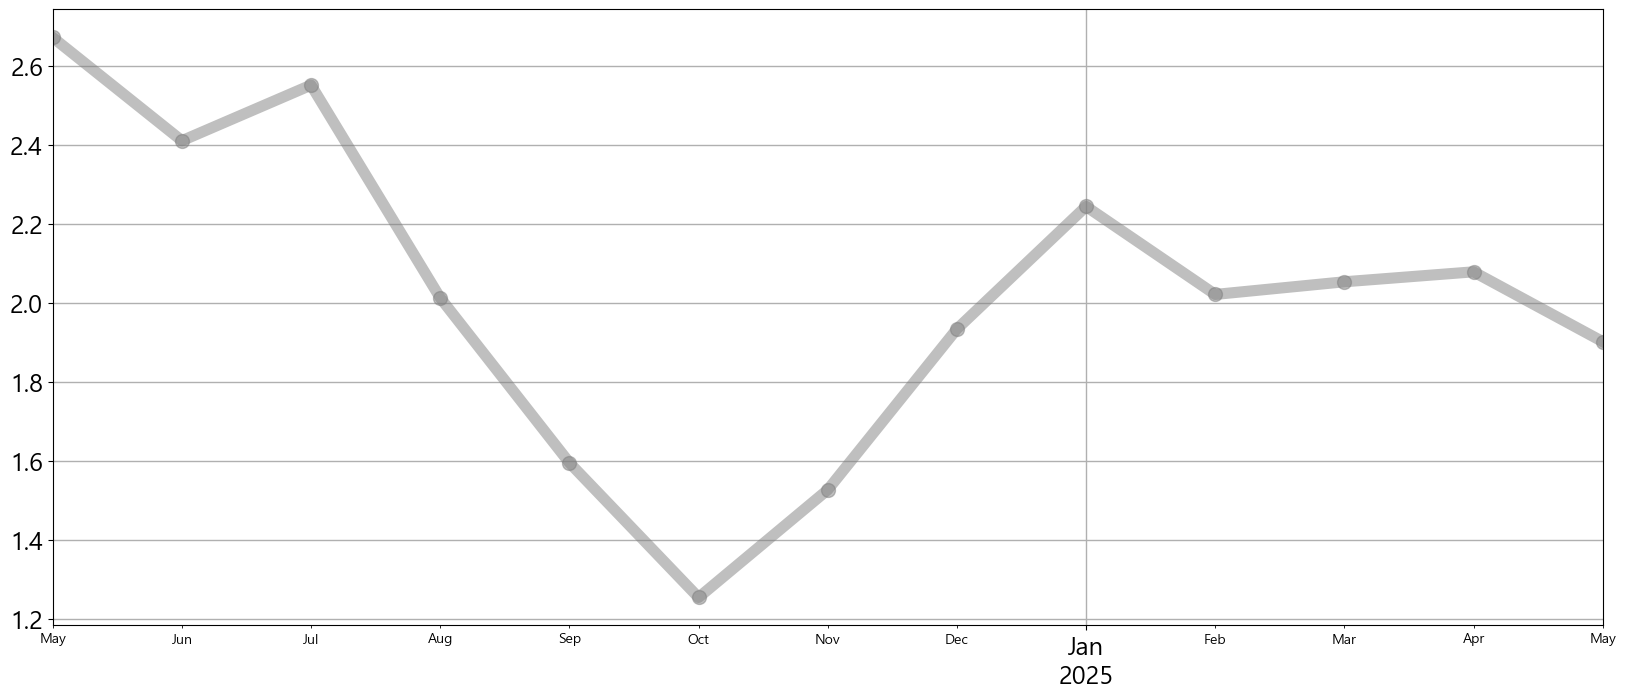

In [106]:
fig, axs = plt.subplots(1, 1, figsize=(20, 8))
for ax, h in zip([axs], [0]):
    act[targets].loc['2006':].plot(ax=ax, lw=8, color='gray', marker='o', markersize=10, alpha=0.5)
    #ax.grid(which='minor', lw=1)
    ax.grid(which='major', lw=1)
    #ax.legend(fontsize=14)
    #ax.set_title(f"h = {h}", fontsize=16)
    ax.tick_params(axis="both", labelsize=18)
    for x in ['2018-11-30', '2020-10-31', '2022-07-31']:
        ax.axvline(x=x, lw=6, color='y', alpha=0.5)

# 전망시계별 전망모형

In [107]:
ens_sel = {0:49, 3:94, 12:43}

## 기여도분해

In [108]:
fms = [pd.Timestamp(date+'-1') for date # data + '-1' = 2025-06-1 -> 2025-06-01 파싱
       #in ['2020-10', '2022-7', '2023-7', '2023-8', '2023-9', '2023-10', '2023-11']]
       in ['2025-1']]

In [109]:
fms

[Timestamp('2025-01-01 00:00:00')]

In [110]:
#[month + MonthEnd(0) for month in pd.date_range('2023-8-1', '2023-9-1', freq='M')]
#for month in pd.date_range('2023-8-1', '2023-9-1', freq='M'):
for month in fms:

    fm = month + MonthEnd(0)

    today = nth_friday(fm.year, fm.month, 1)
    _, act_vintage = get_train_data_v5(DF_vintages[today])
    last_inf_month = act_vintage.dropna().index[-1]
    last_inf = act_vintage.dropna().iloc[-1]
    #print(f"The latest inflation is {last_inf:.2f} for {last_inf_month:%Y-%m}")

    for h in [0, 3, 12]:

        tm = fm + MonthEnd(h)
        model_names = ens_models[ens_sel[h]]
        print(f"\nhor : {h} months, fm : {fm:%Y-%m}, tm : {tm:%Y-%m}")
        print(', '.join(model_names))

        PRED_DECOMP = pd.DataFrame()

        for mname in model_names: # 앙상블 구성 모형별 반복
            mname = mname.split('_IN')[0]
            print(f"\ndecomposing {mname} ...")
            try:
                model = joblib.load(f"model/{mname}_{tm.year}-01_h{h}.pkl")
            except:
                print(f"Model for {tm.year - 1} is loaded instead of {tm.year}, which does NOT exist.")
                model = joblib.load(f"model/{mname}_{tm.year - 1}-01_h{h}.pkl")

            fm_vintages = [date for date in vintages if (date.month == fm.month) and (date.year == fm.year)]

            if h == 0:
                pm = fm - MonthEnd(1)
                pm_vintages = [nth_friday(pm.year, pm.month, i) for i in [-3, -2, -1]] # 3, 2, 1주 전 금요일
            else:
                pm_vintages = [nth_friday(m.year, m.month, -1) for m in [fm - MonthEnd(i) for i in [3, 2, 1]]] # 3, 2, 1 개월 전 마지막 금요일

            decomp_vintages = pm_vintages + fm_vintages
            pred = pd.DataFrame(index=decomp_vintages, columns=['forecast'])

            rolling = int(mname.split('_roll')[1].split('_')[0])
            lag = int(mname.split('_lag')[1].split('_')[0])

            if mname.split('_')[0] == 'lm':
                data_group = mname.split('_model')[1].split('-')
                excl_alt = False
            else:
                data_group = int(mname.split('_g')[1].split('_')[0])
                excl_alt = True

            df0 = DF_vintages[decomp_vintages[0]].copy()
            X0, _ = get_train_data_v5(df0, lag, data_group, excl_alt, fm, rolling=rolling)

            if mname.split('_')[0] == 'lm':
                pred0 = model.predict(X0.loc[[fm]])[0]
            else:
                if h == 12:
                    X0 = X0.drop(['P_eir'], axis = 1) # 12개월 전망 기대인플레 제외
                else:
                    pass
                pred0 = model.predict(X0.loc[[fm]])[0] + last_inf

            decomp = pd.DataFrame(index=decomp_vintages[1:], columns=df0.columns)
            pred.loc[decomp_vintages[0], 'forecast'] = pred0

            for v in decomp_vintages[1:]:
                print(f"{v:%m-%d}", end=' ')
                df1 = DF_vintages[v].copy()

                for col in df0.columns:
                    df0 = df0.reindex(df1.index) # 인덱스 맞추기
                    df0.loc[:, col] = df1.loc[:, col].copy()
                    X1, _ = get_train_data_v5(df0, lag, data_group, excl_alt, fm, rolling=rolling)
                    if mname.split('_')[0] == 'lm':
                        pred1 = model.predict(X1.loc[[fm]])[0]
                    else:
                        if h == 12:
                            X1 = X1.drop(['P_eir'], axis = 1) # 12개월 전망 기대인플레 제외
                        else:
                            pass
                        pred1 = model.predict(X1.loc[[fm]])[0] + last_inf
                    diff = pred1 - pred0
                    if np.abs(diff) > 0.001:
                        print(f"({col}){diff:.3f}", end=' ')
                    decomp.loc[v, col] = diff
                    pred0 = pred1

                pred.loc[v, 'forecast'] = pred1
                print(f"({pred1:.3f})")

            decomp = decomp.applymap(lambda x: np.nan if np.abs(x) < 0.0001 else x)
            decomp = decomp.dropna(how='all', axis=1)
            pred_decomp = pd.concat([pred, decomp], axis=1)
            pred_decomp = pd.concat([pred_decomp], axis=1, keys=[mname])
            PRED_DECOMP = pd.concat([PRED_DECOMP, pred_decomp], axis=1)

        PRED_DECOMP.to_pickle(f"output/decomp_{fm:%Y-%m-%d}_{h}.pkl")


hor : 0 months, fm : 2025-01, tm : 2025-01
lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN, lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN, lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN, ext_roll0_lag0_d6_g1_IN

decomposing lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3 ...
12-20 (RE_atpi_1)0.028 (GB_cp_3)0.008 (1.662)
12-27 (1.662)
01-03 (P_cpi_1)0.419 (GB_cp_3)0.013 (2.094)
01-10 (GB_cp_3)0.003 (2.097)
01-17 (RE_atpi_1)-0.058 (GB_cp_3)0.011 (2.051)
01-24 (2.051)
01-31 (GB_cp_3)-0.003 (2.048)

decomposing lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3 ...
12-20 (RE_atpi_1)0.009 (GB_cp_3)0.009 (1.611)
12-27 (1.612)
01-03 (P_cpi_1)0.416 (GB_cp_3)0.013 (2.040)
01-10 (GB_cp_3)0.003 (2.043)
01-17 (RE_atpi_1)-0.045 (GB_cp_3)0.011 (2.009)
01-24 (2.009)
01-31 (GB_cp_3)-0.003 (2.006)

decomposing lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3 ...
12-20 (RE_atpi_1)0.031 (GB_cp_3)0.003 (1.667)
12-27 (1.667)
01-03 (P_cpi_1)0.410 (GB_cp_3)-0.010 (2.067)
01-10 (GB_cp_3)-0.004 (2.063)


c:\Users\bok\anaconda3\envs\myenv\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ExtraTreeRegressor from version 1.2.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


12-20 (1.877)
12-27 (1.877)
01-03 (P_eadm)0.002 (PB_ipi_1)-0.002 (PB_mavor)-0.003 (PB_ioi_1)-0.005 (PB_ioi_3)-0.002 (IE_mir_1)0.001 (IE_mir_6)0.002 (IE_mir_7)0.005 (IE_ex_1)-0.002 (IE_mir_11)0.001 (IE_mir_8)-0.002 (S_spi_1)-0.048 (GB_cp_3)0.005 (1.831)
01-10 (GB_cp_3)0.001 (1.832)
01-17 (P_ipi_1)0.002 (L_eap_7)0.006 (L_eap_10)0.007 (EI_ivi_1)0.001 (EI_tti_2)-0.003 (GB_cp_3)0.005 (1.851)
01-24 (1.851)
01-31 (1.851)

hor : 3 months, fm : 2025-01, tm : 2025-04
lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN, lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN, lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN, ext_roll0_lag0_d6_g1_IN

decomposing lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3 ...
11-29 (P_cpi_1)-0.293 (P_ipi_6)-0.018 (RE_atpi_1)-0.018 (GB_cp_3)-0.008 (1.151)
12-27 (P_cpi_1)0.176 (P_ipi_6)0.004 (RE_atpi_1)0.005 (GB_cp_3)0.036 (1.373)
01-03 (P_cpi_1)0.297 (GB_cp_3)0.001 (1.671)
01-10 (1.671)
01-17 (P_ipi_6)0.007 (RE_atpi_1)-0.052 (1.625)
01-24 (1.625)
01-31 (1.625)

d

c:\Users\bok\anaconda3\envs\myenv\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ExtraTreeRegressor from version 1.2.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


FileNotFoundError: [Errno 2] No such file or directory: 'model/ext_roll0_lag0_d6_g1_2024-01_h3.pkl'

## 전망결과 차트



forecasting horizon: 0
12-20:	RE_atpi_1 (+0.010)   GB_cp_3   (+0.004)   P_ppi_35  (+0.000)   P_ppi_1   (+0.000)   LM_hl_5   (-0.000)   C_rsi_1   (+0.000)   EI_iai_1  (+0.000)   
12-27:	IE_mir_13 (+0.000)   GB_cp_3   (+0.000)   P_eir     (-0.000)   C_rsi_1   (+0.000)   EI_iai_1  (+0.000)   EI_ivi_1  (+0.000)   EI_tti_2  (+0.000)   
01-03:	P_cpi_1   (+0.311)   S_spi_1   (-0.010)   GB_cp_3   (-0.003)   IE_mir_8  (-0.001)   PB_ioi_1  (+0.001)   PB_ioi_3  (+0.001)   IE_mir_7  (+0.001)   
01-10:	GB_cp_3   (-0.001)   GB_chn_2  (-0.000)   C_rsi_1   (+0.000)   EI_iai_1  (+0.000)   EI_ivi_1  (+0.000)   EI_tti_2  (+0.000)   GB_us_1   (+0.000)   
01-17:	RE_atpi_1 (-0.031)   P_ipi_6   (+0.030)   GB_cp_3   (-0.006)   L_eap_7   (+0.003)   L_eap_10  (+0.001)   EI_iai_1  (+0.001)   EI_tti_2  (-0.000)   
01-24:	P_eir     (+0.000)   P_ppi_35  (-0.000)   GB_cp_3   (-0.000)   C_rsi_1   (+0.000)   EI_iai_1  (+0.000)   EI_ivi_1  (+0.000)   EI_tti_2  (+0.000)   
01-31:	GB_cp_3   (+0.002)   IE_mir_13 (+0.000

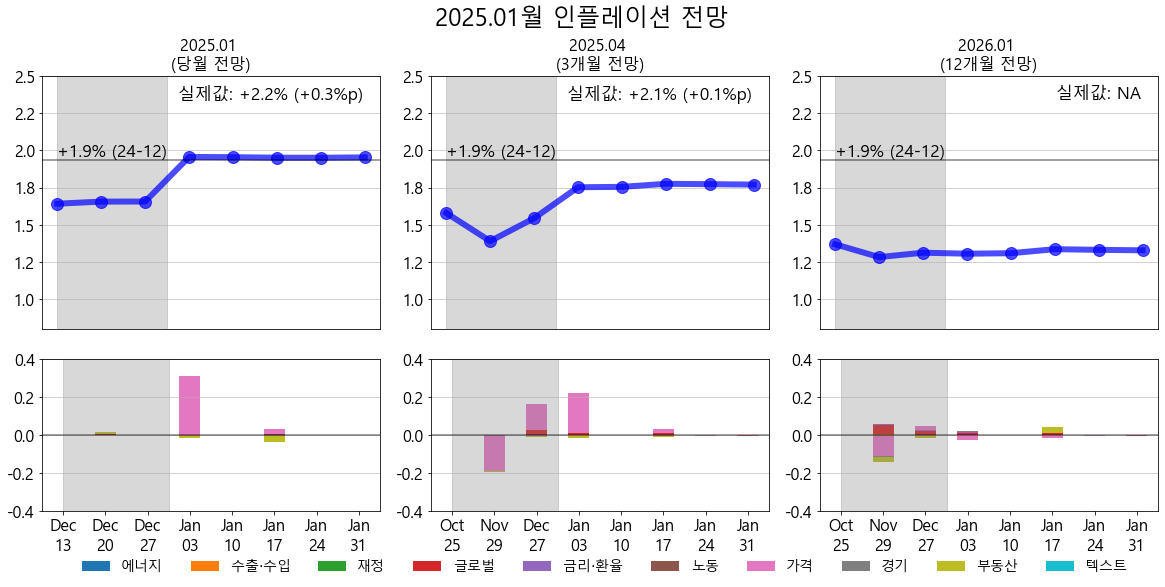

In [ ]:
fm = pd.Timestamp('2025-1-1') + MonthEnd()

fig, axs = plt.subplots(2, 3, figsize=(20, 8),
                        gridspec_kw={'width_ratios': [3, 3, 3], 'height_ratios': [5, 3],
                                     'wspace': 0.15, 'hspace': 0.15})
margin = 0.5
margin0 = 0.1

DECOMP_VAR = {}

vspec = pd.read_excel('input/data_list_all_v9.xlsx', index_col = None)
vspec.index.names = [None]
vspec['group'] = vspec['My ID'].str.split('_', expand=True)[0] # expand=True: 분할된 결과를 새로운 열로 추가
id_group = vspec[['My ID', 'group']].set_index('My ID').to_dict()['group'] # {id : group} 딕셔너리 만들기

_, act = get_train_data_v5(DF_vintages[vintages[-1]])
act = act.dropna()

pm = fm - MonthEnd(1)

ymax = act.loc[pm] # 예측치 차트 최대값
ymin = act.loc[pm] # 예측치 차트 최소값
dymax = 0 # 변동요인 차트 최대값
dymin = 0 # 변동요인 차트 최소값

for i, h in enumerate([0, 3, 12]):
    tm = fm + MonthEnd(h)

    PRED_DECOMP = pd.read_pickle(f"output/decomp_{fm:%Y-%m-%d}_{h}.pkl")
    pred_decomp_mean = PRED_DECOMP.groupby(level=1, axis=1).sum() # 모형별 decomp, forecast 결과를 sum
    pred_decomp_mean = (pred_decomp_mean / len(PRED_DECOMP.columns.get_level_values(0).unique()))
    DECOMP_VAR[h] = pred_decomp_mean
    decomp = pred_decomp_mean.rename(columns=id_group) # {id : group} 딕셔너리로 변수명을 그룹명으로 바꾸기
    decomp = decomp.groupby(decomp.columns, axis=1).sum() # 그룹별 sum

    today = decomp.index[-1]
    _, act_vintage = get_train_data_v5(DF_vintages[today])
    last_inf = act_vintage.dropna().iloc[-1]

    forecast = decomp.pop('forecast') # pop 열 추출하고 삭제
    decomp = decomp.reindex(columns=vspec.group.unique())
    decomp = decomp.rename(columns={'LM':'IE', 'S':'RE', 'C':'PB'}) # 그룹 합치기
    decomp = decomp.groupby(decomp.columns, axis=1).sum()
    decomp = decomp.rename(columns={'EG':'에너지', 'EI':r'수출$\cdot$수입', 'F':'재정', 'GB':'글로벌',
                                    'IE':r'금리$\cdot$환율', 'L':'노동', 'P':'가격', 'PB':'경기', 'RE':'부동산','T':'텍스트'})

    #diff = forecast - last_inf
    #diff = diff.to_frame('change w.r.t. last infl.')
    df = pd.concat([forecast, decomp], axis=1)
    df = df.reindex(sorted(list(set(df.index.tolist() + [nth_friday(fm.year, fm.month, i) for i in [-4, -3, -2, -1]]))))
    ticklabels = [t.strftime("%b\n%d") for t in df.index]
    df.index = np.arange(len(df.index)) # arrange: 인덱스를 0부터 시작하는 정수 배열로 변환

    df['forecast'].plot(ax=axs[0, i], lw=6, marker="o", color='b', markersize=12, alpha=0.7)
    #axs[0, i].plot(df.index, df.fillna(df.mean())['forecast'], alpha=0, color='b')
    #axs[0, i].plot(ticklabels, df.iloc[:, 0], lw=4, marker="o", markersize=12)
    df.iloc[:, 1:].plot.bar(stacked=True, ax=axs[1, i]) # 변동요인 바차트
    #axs[1, i].plot(df.index, df.fillna(df.mean())['forecast'], alpha=0, color='b')
    axs[1, i].set_xticklabels(ticklabels, rotation=0)
    
    axs[0, i].yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f')) # y축 소수점 1자리까지만 표시
    axs[1, i].yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))
    
    axs[0, i].axhline(y=last_inf, lw=1.5, color='k', alpha=0.5) # 마지막 인플레이션 수평선
    axs[1, i].axhline(y=0, lw=1.5, color='k', alpha=0.5) # 0 수평선
    ymin = min(df.iloc[:, 0].min(), ymin) # 최소값 업데이트
    ymax = max(df.iloc[:, 0].max(), ymax) # 최대값 업데이트
    dymax = max(np.abs(df.iloc[:, 1:]).sum(axis=1).max(), dymax) # 변동요인 y축 최대값 업데이트
    axs[1, i].legend(ncol=14, loc=3, frameon=False, bbox_to_anchor=(0.08, -0.5), fontsize=14)
    axs[0, i].grid(alpha=0.7, axis='y')
    axs[1, i].grid(alpha=0.7, axis='y')
    if h == 0:
        axs[0, i].set_title(f"{tm:%Y.%m} \n(당월 전망)", fontsize=16)
    else:
        axs[0, i].set_title(f"{tm:%Y.%m} \n({h}개월 전망)", fontsize=16)
    axs[0, i].tick_params(axis="both", labelsize=16)
    axs[1, i].tick_params(axis="both", labelsize=16)
    axs[0, i].get_xaxis().set_visible(False) # 상단 차트 tick 숨기기
    axs[0, i].text(0.0, last_inf, f"{act.loc[pm]:+.1f}% ({pm:%y-%m})", fontsize=17,
                       horizontalalignment='left', verticalalignment='bottom') # 마지막 인플레이션 텍스트로 넣기
    if i > 0:
        axs[1, i].get_legend().remove() # 변수별 그룹 범례 중복 방지
    try:
        axs[0, i].text(0.95, 0.93, f"실제값: {act.loc[tm]:+.1f}% ({act.loc[tm]-act.loc[pm]:+.1f}%p)", fontsize=17,
                       horizontalalignment='right', verticalalignment='center', transform=axs[0, i].transAxes)
    except:
        axs[0, i].text(0.95, 0.93, f"실제값: NA", fontsize=17,
                       horizontalalignment='right', verticalalignment='center', transform=axs[0, i].transAxes)

    axs[0, i].fill_between((0, 2.5), -10, 10, color='gray', alpha=.3) # 해당월 이전은 음영 처리
    axs[1, i].fill_between((0, 2.5), -10, 10, color='gray', alpha=.3) # -10~10 음영 처리

for i, h in enumerate([0, 3, 12]):
    axs[0, i].set_ylim(round(ymin - margin, 1), round(ymax + margin, 1)) # 예측치 차트 y축 범위
    axs[1, i].set_ylim(round(-dymax - margin0, 1), round(dymax + margin0, 1)) # 변동요인 차트 y축 범위

fig.suptitle(f"{fm:%Y.%m}월 인플레이션 전망", fontsize=24, y=1.0)   
    
text = ''
for h in [0, 3, 12]:
    text += f"\n\nh {h} "
    print(f"\n\nforecasting horizon: {h}", end='')
    dcomp = DECOMP_VAR[h].drop('forecast', axis=1)
    for i in dcomp.index[1:]:
        vars = np.abs(dcomp).loc[i].nlargest(7).index # 빈티지별 절대값 기준 상위 7개 변수
        text += f"\n{i:%m-%d}:\t"
        print(f"\n{i:%m-%d}:", end='\t')
        for v in vars:
            text += f"{v:<10}({dcomp.loc[i, v]:+.3f})    "
            print(f"{v:<10}({dcomp.loc[i, v]:+.3f})", end='   ')

fig.patch.set_alpha(0.0)